## Preliminaries

In [1]:
# pip install pandas matplotlib seaborn odfpy statsmodels

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import kendalltau, spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import LeaveOneOut, cross_val_predict

## Workload and Results Loading

In [3]:
fdata_1 = pd.read_csv('workloads/fdata/fdata_18k_1.swf', header=None, sep='\t')
fdata_2 = pd.read_csv('workloads/fdata/fdata_18k_2.swf', header=None, sep='\t')
fdata_3 = pd.read_csv('workloads/fdata/fdata_18k_3.swf', header=None, sep='\t')
fdata_4 = pd.read_csv('workloads/fdata/fdata_18k_4.swf', header=None, sep='\t')
fdata_5 = pd.read_csv('workloads/fdata/fdata_18k_5.swf', header=None, sep='\t')

In [4]:
def load_results(path):
    """
    Load results from CSV or ODS file.
    Assumes decimals use '.' and columns are:
    workload, Policy, Estimation, awt, asd
    """
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    elif path.endswith(".ods"):
        df = pd.read_excel(path, engine="odf")
    else:
        raise ValueError("Unsupported file format")

    # Ensure numeric columns are floats
    numeric_cols = ["AWT", "ASD"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    return df

In [5]:
df = load_results('results/fdata_results_h.ods')

In [6]:
df

,Workload,Policy,Estimation,AWT,ASD
0,Heavy_1,1 - SJF,1 - User,6564.22,60.95
1,Heavy_1,1 - SJF,2 - Actual,5322.34,1.73
2,Heavy_1,1 - SJF,3 - Heuristic,6968.10,70.34
3,Heavy_1,1 - SJF,4 - DT,8898.37,16.23
4,Heavy_1,1 - SJF,5 - RNP,10672.49,83.55
...,...,...,...,...,...
100,Heavy_5,3 - PRB,3 - Heuristic,7338.52,102.62
101,Heavy_5,3 - PRB,4 - DT,7274.76,101.77
102,Heavy_5,3 - PRB,5 - RNP,7142.92,99.93
103,Heavy_5,3 - PRB,6 - KNN,7314.21,102.21


## Averages Computation

In [7]:
avg_runtime_h1 = np.mean(fdata_1[3])
avg_runtime_h2 = np.mean(fdata_2[3])
avg_runtime_h3 = np.mean(fdata_3[3])
avg_runtime_h4 = np.mean(fdata_4[3])
avg_runtime_h5 = np.mean(fdata_5[3])

In [8]:
max_runtime_h1 = np.max(fdata_1[3])
max_runtime_h2 = np.max(fdata_2[3])
max_runtime_h3 = np.max(fdata_3[3])
max_runtime_h4 = np.max(fdata_4[3])
max_runtime_h5 = np.max(fdata_5[3])

In [9]:
avg_nodes_h1 = np.mean(fdata_1[4])
avg_nodes_h2 = np.mean(fdata_2[4])
avg_nodes_h3 = np.mean(fdata_3[4])
avg_nodes_h4 = np.mean(fdata_4[4])
avg_nodes_h5 = np.mean(fdata_5[4])

In [10]:
max_nodes_h1 = np.max(fdata_1[4])
max_nodes_h2 = np.max(fdata_2[4])
max_nodes_h3 = np.max(fdata_3[4])
max_nodes_h4 = np.max(fdata_4[4])
max_nodes_h5 = np.max(fdata_5[4])

In [11]:
workload_stats = pd.DataFrame({
    "Workload": ["Heavy_1", "Heavy_2", "Heavy_3", "Heavy_4", "Heavy_5"],
    "avg_runtime": [avg_runtime_h1, avg_runtime_h2, avg_runtime_h3,
                    avg_runtime_h4, avg_runtime_h5],
    "avg_nodes": [avg_nodes_h1, avg_nodes_h2, avg_nodes_h3,
                  avg_nodes_h4, avg_nodes_h5],
    "max_runtime": [max_runtime_h1, max_runtime_h2, max_runtime_h3,
                    max_runtime_h4, max_runtime_h5],
    "max_nodes": [max_nodes_h1, max_nodes_h2, max_nodes_h3,
                  max_nodes_h4, max_nodes_h5]
})

summary_df = df.merge(workload_stats, on="Workload")

In [12]:
workload_stats

,Workload,avg_runtime,avg_nodes,max_runtime,max_nodes
0,Heavy_1,8917.339222,73.826222,255973,34272
1,Heavy_2,9198.980222,75.634944,257417,21120
2,Heavy_3,9480.112944,73.209389,251324,43200
3,Heavy_4,9109.828000,73.921833,257966,15840
4,Heavy_5,9095.293000,70.674222,257966,15360


In [13]:
summary_df

,Workload,Policy,Estimation,AWT,ASD,avg_runtime,avg_nodes,max_runtime,max_nodes
0,Heavy_1,1 - SJF,1 - User,6564.22,60.95,8917.339222,73.826222,255973,34272
1,Heavy_1,1 - SJF,2 - Actual,5322.34,1.73,8917.339222,73.826222,255973,34272
2,Heavy_1,1 - SJF,3 - Heuristic,6968.10,70.34,8917.339222,73.826222,255973,34272
3,Heavy_1,1 - SJF,4 - DT,8898.37,16.23,8917.339222,73.826222,255973,34272
4,Heavy_1,1 - SJF,5 - RNP,10672.49,83.55,8917.339222,73.826222,255973,34272
...,...,...,...,...,...,...,...,...,...
100,Heavy_5,3 - PRB,3 - Heuristic,7338.52,102.62,9095.293000,70.674222,257966,15360
101,Heavy_5,3 - PRB,4 - DT,7274.76,101.77,9095.293000,70.674222,257966,15360
102,Heavy_5,3 - PRB,5 - RNP,7142.92,99.93,9095.293000,70.674222,257966,15360
103,Heavy_5,3 - PRB,6 - KNN,7314.21,102.21,9095.293000,70.674222,257966,15360


### Workloads Averages

In [14]:
def avg_across_workloads(df):
    return (
        df
        .groupby(["Policy", "Estimation"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )


In [15]:
avg_w_1 = avg_across_workloads(df)
avg_w_1.columns = ["Policy", "Estimation", "AWT", "ASD"]

In [16]:
def avg_by_workload(df):
    return (
        df
        .groupby(["Workload"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )


In [17]:
avg_w_2 = avg_by_workload(df)

In [18]:
avg_w_1

,Policy,Estimation,AWT,ASD
0,1 - SJF,1 - User,7251.168,61.902
1,1 - SJF,2 - Actual,5894.516,1.916
2,1 - SJF,3 - Heuristic,7540.970,69.636
3,1 - SJF,4 - DT,10105.480,21.972
4,1 - SJF,5 - RNP,11377.402,81.004
5,1 - SJF,6 - KNN,6366.696,41.336
6,1 - SJF,7 - LLM,6180.996,19.080
7,2 - EASYBF,1 - User,5881.318,85.410
8,2 - EASYBF,2 - Actual,5881.318,85.410
9,2 - EASYBF,3 - Heuristic,5881.318,85.410


### Policies Averages

In [19]:
def avg_across_policies(df):
    return (
        df
        .groupby(["Workload", "Estimation"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )


In [20]:
avg_p_1 = avg_across_policies(df)
avg_p_1

,Workload,Estimation,awt_avg,asd_avg
0,Heavy_1,1 - User,5481.346667,71.643333
1,Heavy_1,2 - Actual,5102.616667,52.480000
2,Heavy_1,3 - Heuristic,5604.963333,74.586667
3,Heavy_1,4 - DT,6300.733333,57.476667
4,Heavy_1,5 - RNP,6803.793333,78.450000
5,Heavy_1,6 - KNN,5203.656667,64.946667
6,Heavy_1,7 - LLM,5120.186667,57.656667
7,Heavy_2,1 - User,5929.030000,71.323333
8,Heavy_2,2 - Actual,5505.216667,55.326667
9,Heavy_2,3 - Heuristic,5966.976667,73.200000


In [21]:
def avg_by_Policy(df):
    return (
        df
        .groupby(["Policy"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )

In [22]:
avg_p_2 = avg_by_Policy(df)
avg_p_2

,Policy,awt_avg,asd_avg
0,1 - SJF,7816.746857,42.406571
1,2 - EASYBF,5886.178000,85.491429
2,3 - PRB,5834.349143,84.401714


### Estimations Averages

In [23]:
def avg_across_Estimations(df):
    return (
        df
        .groupby(["Workload", "Policy"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )

In [24]:
avg_e_1 = avg_across_Estimations(df)
avg_e_1

,Workload,Policy,awt_avg,asd_avg
0,Heavy_1,1 - SJF,7082.975714,41.688571
1,Heavy_1,2 - EASYBF,4999.877143,78.042857
2,Heavy_1,3 - PRB,4895.988571,76.228571
3,Heavy_2,1 - SJF,6361.337143,29.577143
4,Heavy_2,2 - EASYBF,5839.754286,83.285714
5,Heavy_2,3 - PRB,5976.457143,84.731429
6,Heavy_3,1 - SJF,8509.924286,51.605714
7,Heavy_3,2 - EASYBF,5377.471429,82.870000
8,Heavy_3,3 - PRB,5300.495714,81.528571
9,Heavy_4,1 - SJF,7691.987143,35.812857


In [25]:
def avg_by_Estimation(df):
    return (
        df
        .groupby(["Estimation"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg"
        })
    )

In [26]:
avg_e_2 = avg_by_Estimation(df)
avg_e_2

,Estimation,awt_avg,asd_avg
0,1 - User,6313.610667,77.088000
1,2 - Actual,5864.461333,57.158000
2,3 - Heuristic,6415.396000,79.765333
3,4 - DT,7288.782667,64.201333
4,5 - RNP,7711.352667,83.798667
5,6 - KNN,6021.236000,70.267333
6,7 - LLM,5972.133333,63.087333


## Bar Plots

### Helpers

In [27]:
def plot_metrics(df, policy_name="SJF", image_path=""):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    metrics = ['AWT', 'ASD']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_col = f"{metric}"
        
        # Calcolo soglia per il posizionamento del testo (20% del massimo)
        max_val = df[metric_col].max()
        threshold = max_val * 0.20

        # Soglia per l'orientamento del testo (vertical vs horizontal)
        orientation_threshold = 0
        
        # Normalizzazione per la colormap
        norm = plt.Normalize(df[metric_col].min(), df[metric_col].max())
        colors = plt.cm.RdYlGn_r(norm(df[metric_col]))

        # Creazione barre
        bars = ax.bar(df['Estimation'], df[metric_col], color=colors, alpha=0.8)

        # Aggiunta valori (Logica per centro barra e rotazione verticale)
        for bar in bars:
            yval = bar.get_height()
            
            # Determiniamo se il valore deve essere verticale (> 1000)
            rotation = 'vertical' if yval > orientation_threshold else 'horizontal'
            
            if yval < threshold:
                # Sopra la barra
                y_pos = yval + (max_val * 0.02)
                va_pos = 'bottom'
            else:
                # Al centro della barra
                y_pos = yval / 2
                va_pos = 'center'

            ax.text(
                bar.get_x() + bar.get_width()/2, 
                y_pos, 
                round(yval, 4), 
                ha='center', 
                va=va_pos, 
                rotation=rotation, # Applica rotazione verticale se > 1000
                color='black'
            )

        ax.set_title(f'{policy_name} - {metric.upper()}', fontsize=14)
        ax.set_ylabel(metric.upper())
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Ruota le etichette X a 45 gradi per ogni subplot
        ax.tick_params(axis='x', labelrotation=45)

    plt.tight_layout()

    # Salvataggio opzionale
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

def plot_metrics_horizontal(df, policy_name="SJF", max_values=None, image_path=""):
    """
    max_values: dict opzionale, es: {'AWT': 5000, 'ASD': 200, 'ASU': 1}
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    metrics = ['AWT', 'ASD']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_col = f"{metric}"
        
        # 1. Gestione della scala fissa
        # Se max_values è fornito, usiamo quello, altrimenti usiamo il max del dataframe corrente
        current_max = df[metric_col].max()
        limit_val = max_values[metric] if (max_values and metric in max_values) else current_max
        
        # Soglia per il testo basata sul limite dell'asse (per coerenza visiva)
        threshold = limit_val * 0.20
        
        # Normalizzazione colori (sempre basata sui dati reali del DF)
        norm = plt.Normalize(df[metric_col].min(), df[metric_col].max())
        colors = plt.cm.RdYlGn_r(norm(df[metric_col]))

        # Creazione barre orizzontali
        bars = ax.barh(df['Estimation'], df[metric_col], color=colors, alpha=0.8)

        # 2. Impostazione del limite dell'asse X
        ax.set_xlim(0, limit_val)

        # Aggiunta valori numerici
        for bar in bars:
            xval = bar.get_width()
            
            # Se il valore eccede il limite (per errore), lo clip-piamo per il posizionamento
            display_x = min(xval, limit_val)
            
            if xval < threshold:
                x_pos = display_x + (limit_val * 0.02)
                ha_pos = 'left'
            else:
                x_pos = display_x / 2
                ha_pos = 'center'

            ax.text(
                x_pos, 
                bar.get_y() + bar.get_height()/2, 
                round(xval, 4), 
                ha=ha_pos, 
                va='center', 
                color='black',
                fontsize=11
            )

        ax.set_title(f'{metric.upper()}', fontsize=20, pad=20)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=14)
        
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        
    plt.tight_layout()

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")

    plt.show()

### Plots

Grafico salvato in: images/18000x158976/bar_plot_sjf_F2.png


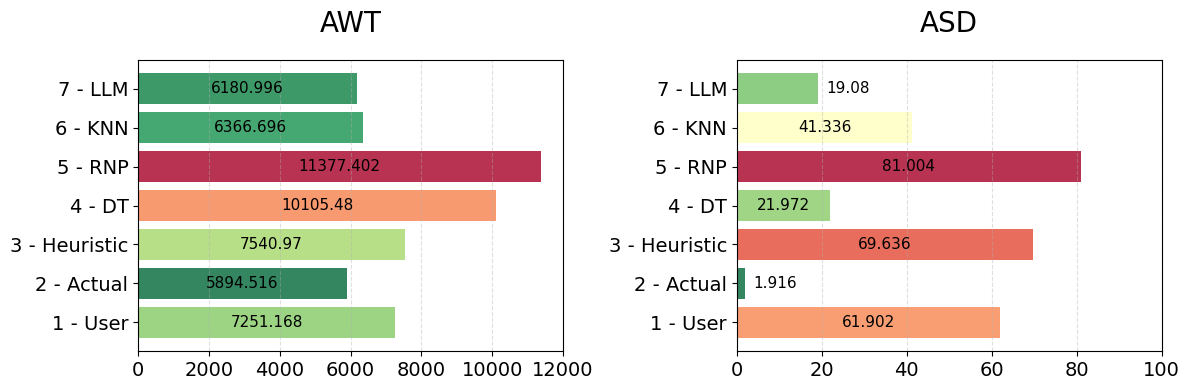

In [28]:
plot_metrics_horizontal(avg_w_1[0:7], policy_name="SJF", max_values={'AWT': 12000, 'ASD': 100, 'ASU': 100}, image_path="images/18000x158976/bar_plot_sjf_F2.png")

Grafico salvato in: images/18000x158976/bar_plot_easy_F2.png


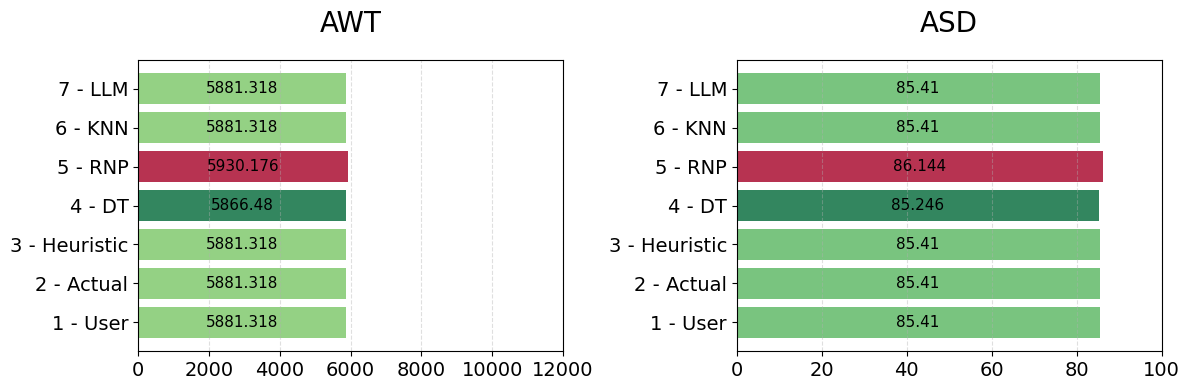

In [29]:
plot_metrics_horizontal(avg_w_1[7:14], policy_name="EASYBF", max_values={'AWT': 12000, 'ASD': 100, 'ASU': 100}, image_path="images/18000x158976/bar_plot_easy_F2.png")

Grafico salvato in: images/18000x158976/bar_plot_prb_F2.png


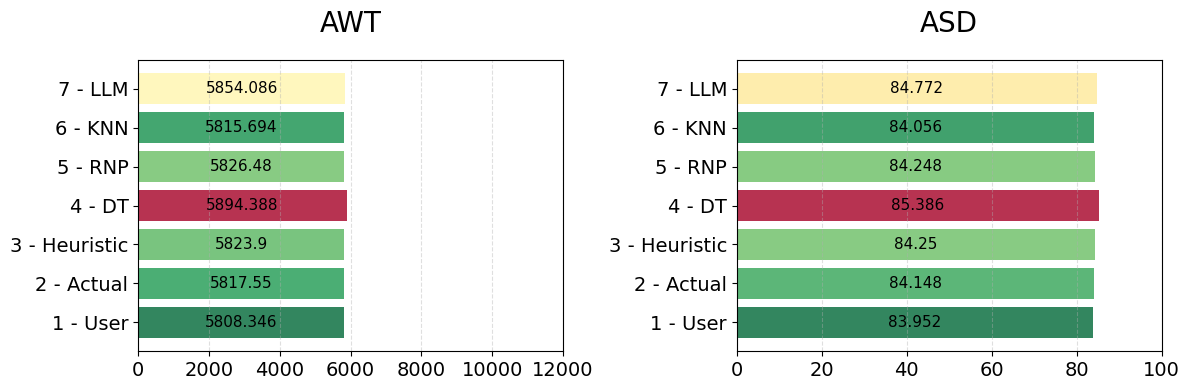

In [30]:
plot_metrics_horizontal(avg_w_1[14:21], policy_name="PRB", max_values={'AWT': 12000, 'ASD': 100, 'ASU': 100}, image_path="images/18000x158976/bar_plot_prb_F2.png")

## Heatmaps

In [31]:
def heatmap_avg_across_workloads(avg_df, metric, approx=".2f", image_path=""):
    pivot = avg_df.pivot(
        index="Policy",
        columns="Estimation",
        values=f"{metric}"
    )

    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt=approx, cmap="RdYlGn_r", cbar=False)
    plt.title(f"{metric.upper()}")
    plt.xticks(rotation = 45)
    plt.yticks(rotation = 45)
    plt.tight_layout()

    # Salvataggio opzionale
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [32]:
avg_w_1

,Policy,Estimation,AWT,ASD
0,1 - SJF,1 - User,7251.168,61.902
1,1 - SJF,2 - Actual,5894.516,1.916
2,1 - SJF,3 - Heuristic,7540.970,69.636
3,1 - SJF,4 - DT,10105.480,21.972
4,1 - SJF,5 - RNP,11377.402,81.004
5,1 - SJF,6 - KNN,6366.696,41.336
6,1 - SJF,7 - LLM,6180.996,19.080
7,2 - EASYBF,1 - User,5881.318,85.410
8,2 - EASYBF,2 - Actual,5881.318,85.410
9,2 - EASYBF,3 - Heuristic,5881.318,85.410


Grafico salvato in: images/18000x158976/heatmap_awt_F2.png


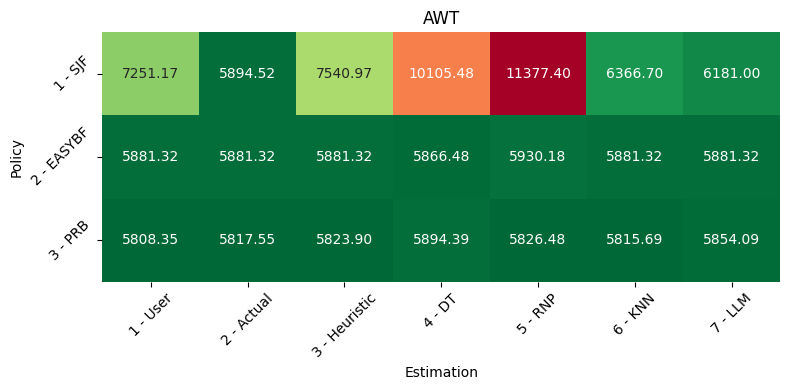

In [33]:
heatmap_avg_across_workloads(avg_w_1, "AWT", image_path="images/18000x158976/heatmap_awt_F2.png")

Grafico salvato in: images/18000x158976/heatmap_asd_F2.png


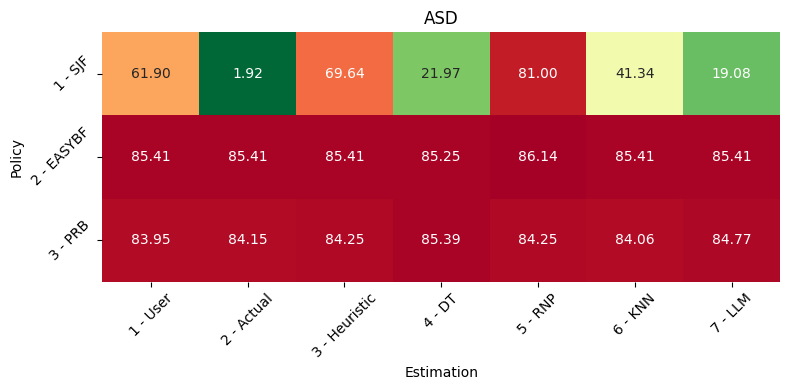

In [34]:
heatmap_avg_across_workloads(avg_w_1, "ASD", image_path="images/18000x158976/heatmap_asd_F2.png")

## Workload Statistics vs Averages-Across-Workloads

### Correlation analysis

In [35]:
def correlation_with_workload_stats(df, workload_stats):
    merged = df.merge(workload_stats, on="Workload")

    correlations = merged[[
        "AWT", "ASD", "avg_runtime", "avg_nodes", 
    ]].corr()

    return correlations

In [36]:
corr = correlation_with_workload_stats(df, workload_stats)
corr

,AWT,ASD,avg_runtime,avg_nodes
AWT,1.000000,-0.018349,0.036634,-0.394495
ASD,-0.018349,1.000000,0.033346,-0.265202
avg_runtime,0.036634,0.033346,1.000000,0.049210
avg_nodes,-0.394495,-0.265202,0.049210,1.000000


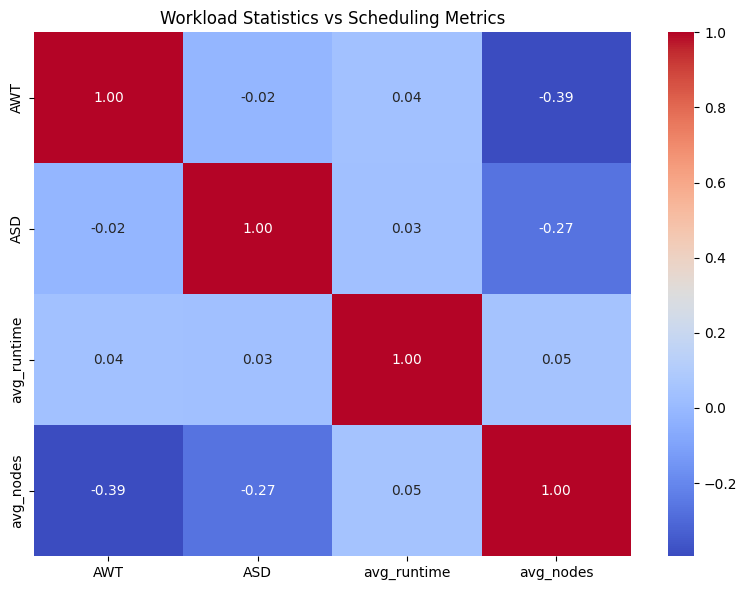

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Workload Statistics vs Scheduling Metrics")
plt.tight_layout()
plt.show()

## Estimation Accuracy vs Scheduling Metrics

### Metrics Loading

In [38]:
acc_df = pd.read_csv("results/fdata_metrics_h.csv")

# Keep only workloads used in scheduling
acc_df = acc_df[acc_df["Workload"].isin(["Heavy_1", "Heavy_2", "Heavy_3", "Heavy_4", "Heavy_5"])]

In [39]:
acc_df

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - User,03:32:14,12734.325333,0.415510,16.712898,0.684601,12734.325333,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,3 - Heuristic,01:12:42,4362.756722,0.527931,5.916221,0.602494,2559.345747,6857.638981,0.577333,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,4 - DT,00:45:32,2732.920278,0.686213,0.813249,0.740257,2091.337846,3672.016271,0.455500,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,5 - RNP,00:54:17,3257.819000,0.635233,1.903771,0.684629,3705.540776,3014.187702,0.472778,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
5,Heavy_1,6 - KNN,00:38:27,2307.369278,0.729893,4.477197,0.797298,2084.471939,2750.916258,0.403889,...,1706.538497,0.198223,0.695155,0.106622,10644.637011,5324.526606,13185.794040,0.323250,0.676750,0.000000
6,Heavy_1,7 - LLM,00:28:23,1703.435833,0.851143,2.177579,0.862404,2551.646928,2297.262152,0.374333,...,2000.652124,0.378358,0.366088,0.255553,5275.701068,3850.065183,9155.786421,0.373072,0.419336,0.207592
7,Heavy_2,1 - User,03:33:49,12829.908444,0.416444,14.670395,0.684215,12829.908444,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31036.813481,31036.813481,0.000000,1.000000,0.000000,0.000000
8,Heavy_2,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
9,Heavy_2,3 - Heuristic,01:13:36,4416.000889,0.533155,5.233531,0.611068,2492.025055,7091.758214,0.578722,...,5064.012156,0.473308,0.525946,0.000746,18540.604881,7034.406375,23279.006563,0.291691,0.708309,0.000000


In [40]:
summary_df = df.merge(
    acc_df,
    on=["Workload", "Estimation"],
    how="left"
)

In [41]:
summary_df

,Workload,Policy,Estimation,AWT,ASD,Average Error,MAE,EA,MAPE,TAU,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - SJF,1 - User,6564.22,60.95,03:32:14,12734.325333,0.415510,16.712898,0.684601,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,1 - SJF,2 - Actual,5322.34,1.73,00:00:00,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,1 - SJF,3 - Heuristic,6968.10,70.34,01:12:42,4362.756722,0.527931,5.916221,0.602494,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,1 - SJF,4 - DT,8898.37,16.23,00:45:32,2732.920278,0.686213,0.813249,0.740257,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,1 - SJF,5 - RNP,10672.49,83.55,00:54:17,3257.819000,0.635233,1.903771,0.684629,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Heavy_5,3 - PRB,3 - Heuristic,7338.52,102.62,01:14:09,4449.424667,0.531872,5.805197,0.603832,...,5034.908096,0.468006,0.531676,0.000317,17885.826566,6808.792531,22220.425000,0.279582,0.719258,0.001160
101,Heavy_5,3 - PRB,4 - DT,7274.76,101.77,00:47:30,2850.498611,0.686086,1.339357,0.738998,...,1596.270378,0.407509,0.503437,0.089053,17416.313805,9728.769231,21458.902116,0.339327,0.657773,0.002900
102,Heavy_5,3 - PRB,5 - RNP,7142.92,99.93,00:57:06,3426.753111,0.634545,2.304926,0.681118,...,1384.222662,0.416922,0.534849,0.048228,17621.269142,15468.049137,19291.067971,0.436775,0.563225,0.000000
103,Heavy_5,3 - PRB,6 - KNN,7314.21,102.21,00:39:22,2362.037611,0.731067,4.369803,0.797960,...,1738.419061,0.202961,0.695822,0.101216,10430.019142,5477.128302,12628.538526,0.307425,0.692575,0.000000


In [42]:
summary_df = summary_df.dropna()

### Correlation Tables

In [43]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df[corr_cols].corr()

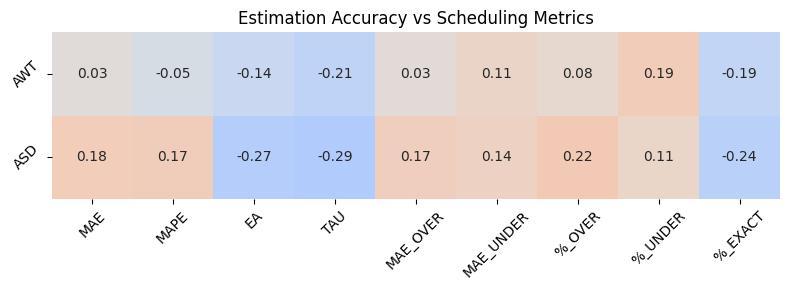

In [44]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -9:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.savefig("images/18000x158976/correlation_all_F2.png", dpi=300)
plt.show()

In [45]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

corr = summary_df[corr_cols].corr()

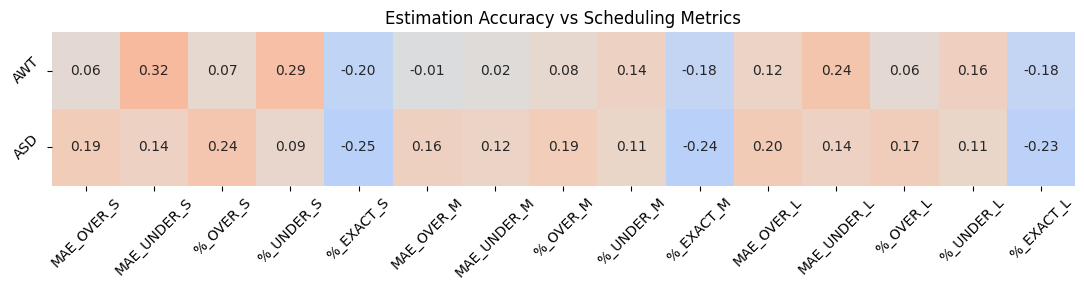

In [46]:
plt.figure(figsize=(11, 3))
sns.heatmap(corr.iloc[0:2, -15:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [47]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU",
]

corr = summary_df[corr_cols].corr()

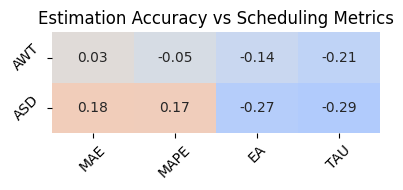

In [48]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [49]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df[corr_cols].corr()

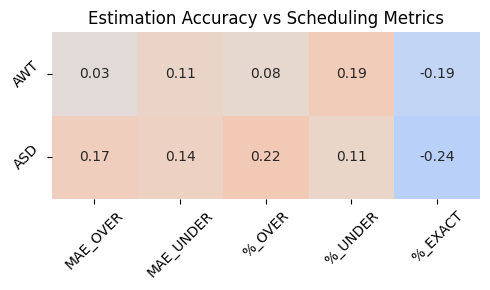

In [50]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

### Scatter plots: Accuracy → Performance

#### Data Preparation

In [51]:
summary_df

,Workload,Policy,Estimation,AWT,ASD,Average Error,MAE,EA,MAPE,TAU,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - SJF,1 - User,6564.22,60.95,03:32:14,12734.325333,0.415510,16.712898,0.684601,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,1 - SJF,2 - Actual,5322.34,1.73,00:00:00,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,1 - SJF,3 - Heuristic,6968.10,70.34,01:12:42,4362.756722,0.527931,5.916221,0.602494,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,1 - SJF,4 - DT,8898.37,16.23,00:45:32,2732.920278,0.686213,0.813249,0.740257,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,1 - SJF,5 - RNP,10672.49,83.55,00:54:17,3257.819000,0.635233,1.903771,0.684629,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Heavy_5,3 - PRB,3 - Heuristic,7338.52,102.62,01:14:09,4449.424667,0.531872,5.805197,0.603832,...,5034.908096,0.468006,0.531676,0.000317,17885.826566,6808.792531,22220.425000,0.279582,0.719258,0.001160
101,Heavy_5,3 - PRB,4 - DT,7274.76,101.77,00:47:30,2850.498611,0.686086,1.339357,0.738998,...,1596.270378,0.407509,0.503437,0.089053,17416.313805,9728.769231,21458.902116,0.339327,0.657773,0.002900
102,Heavy_5,3 - PRB,5 - RNP,7142.92,99.93,00:57:06,3426.753111,0.634545,2.304926,0.681118,...,1384.222662,0.416922,0.534849,0.048228,17621.269142,15468.049137,19291.067971,0.436775,0.563225,0.000000
103,Heavy_5,3 - PRB,6 - KNN,7314.21,102.21,00:39:22,2362.037611,0.731067,4.369803,0.797960,...,1738.419061,0.202961,0.695822,0.101216,10430.019142,5477.128302,12628.538526,0.307425,0.692575,0.000000


In [52]:
summary_df_avg = (
    summary_df
    .groupby(["Policy", "Estimation"])
    .agg({
        "AWT": "mean",
        "ASD": "mean",
        "MAE": "mean",
        "MAPE": "mean",
        "EA": "mean",
        "TAU": "mean"
    })
    .reset_index()
)

In [53]:
summary_df_no_user = summary_df[summary_df['Estimation'] != '1 - User']
summary_df_avg_no_user = summary_df_avg[summary_df_avg['Estimation'] != '1 - User']

#### Plots

In [54]:
def accuracy_vs_metric_by_policy(data, acc_metric, sched_metric):
    g = sns.FacetGrid(
        data,
        col="Policy",
        col_wrap=4,
        height=4,
        sharex=True,
        sharey=True
    )
    g.map_dataframe(
        sns.scatterplot,
        x=acc_metric,
        y=sched_metric,
        hue="Estimation",
        s=100
    )
    g.add_legend()
    g.set_titles("{col_name}")
    g.fig.suptitle(f"{sched_metric} vs {acc_metric} (by Policy)", y=1.05)
    plt.show()


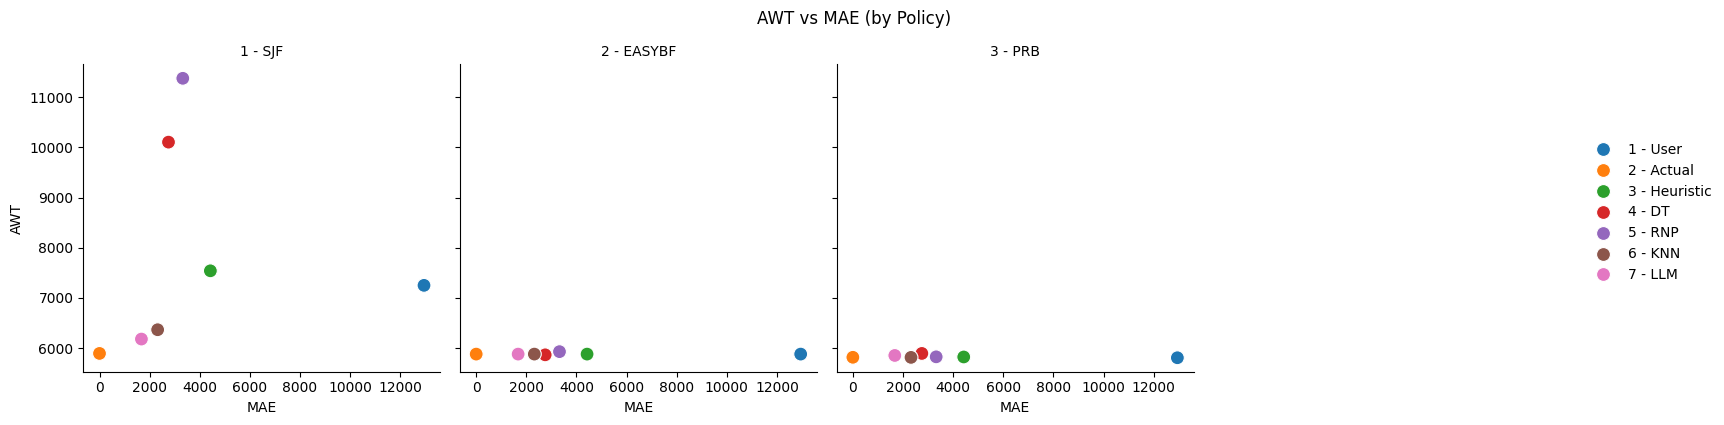

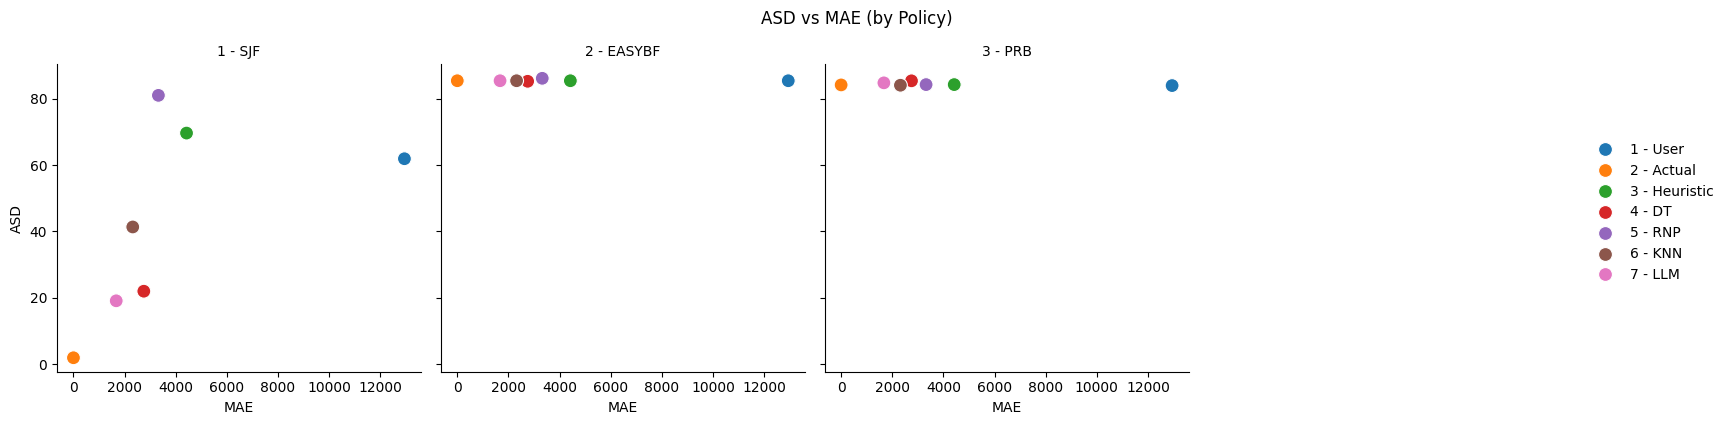

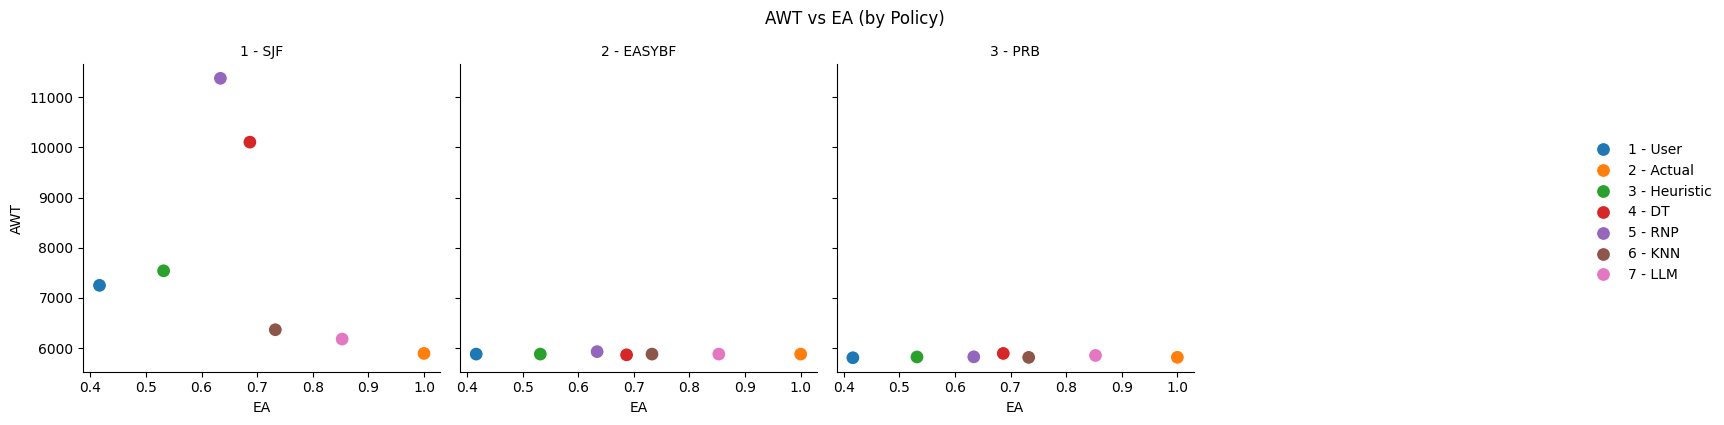

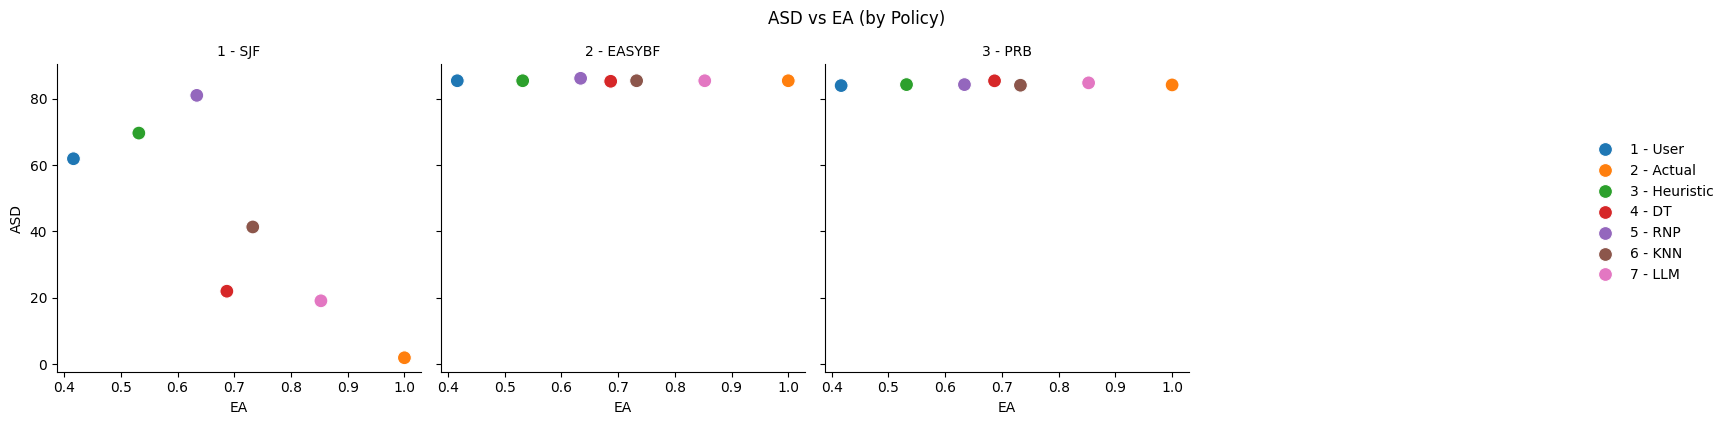

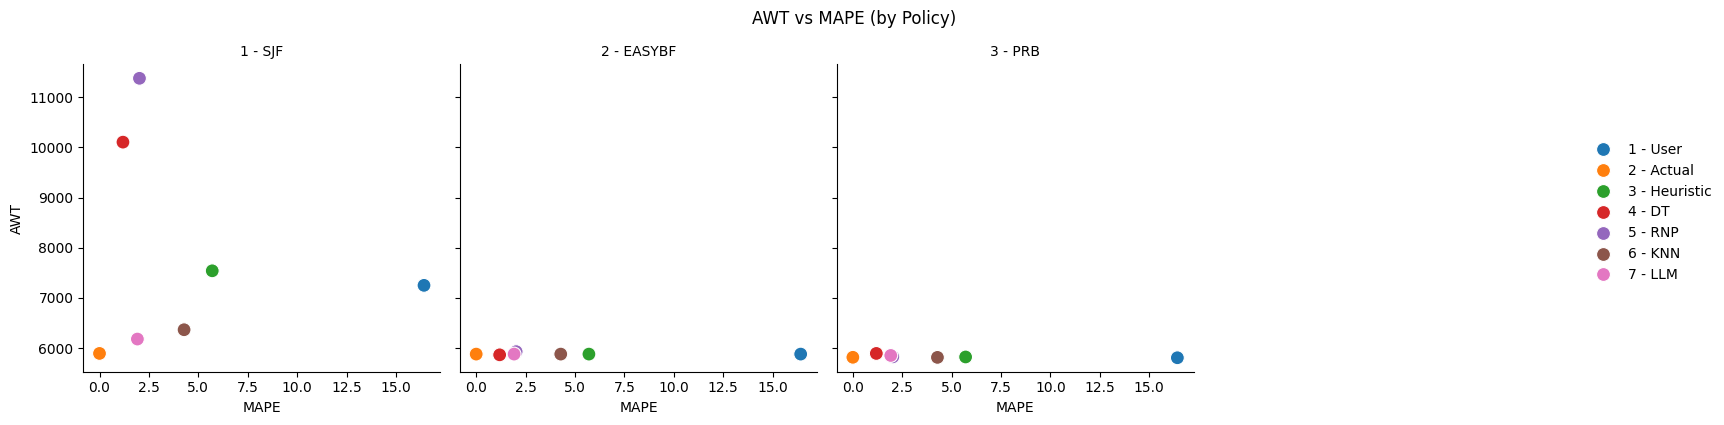

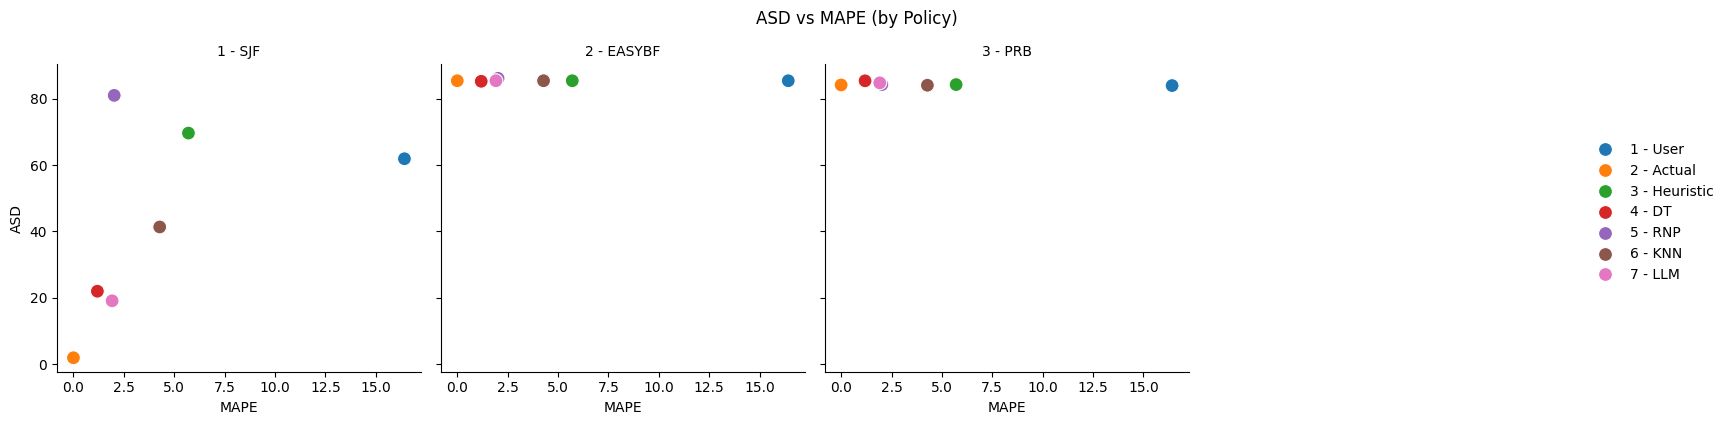

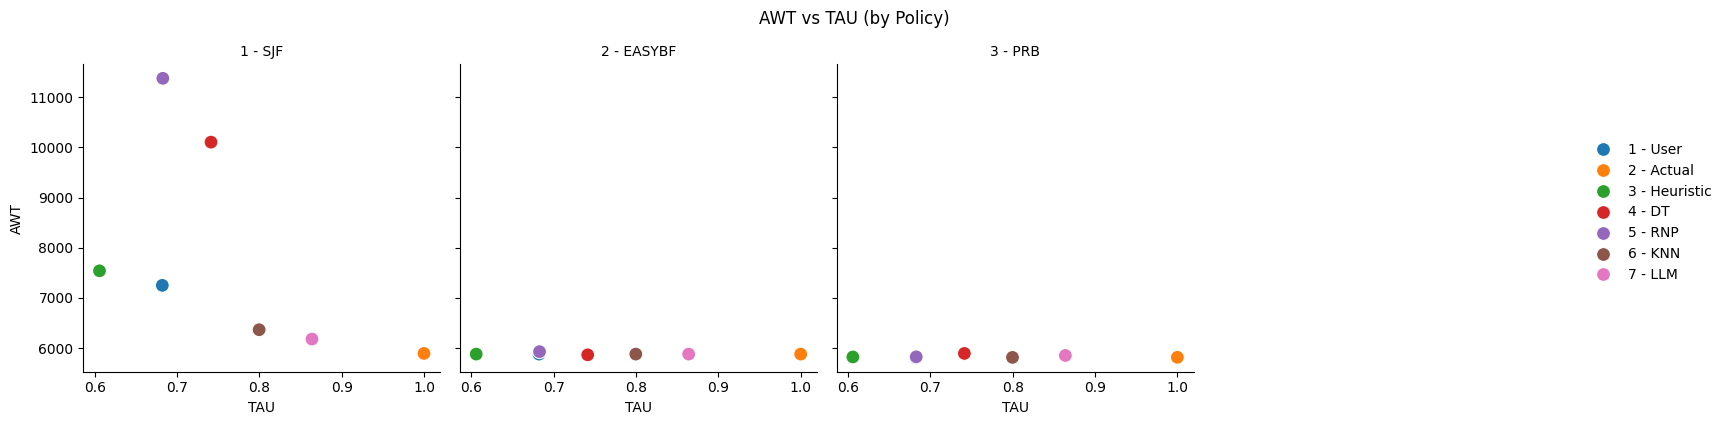

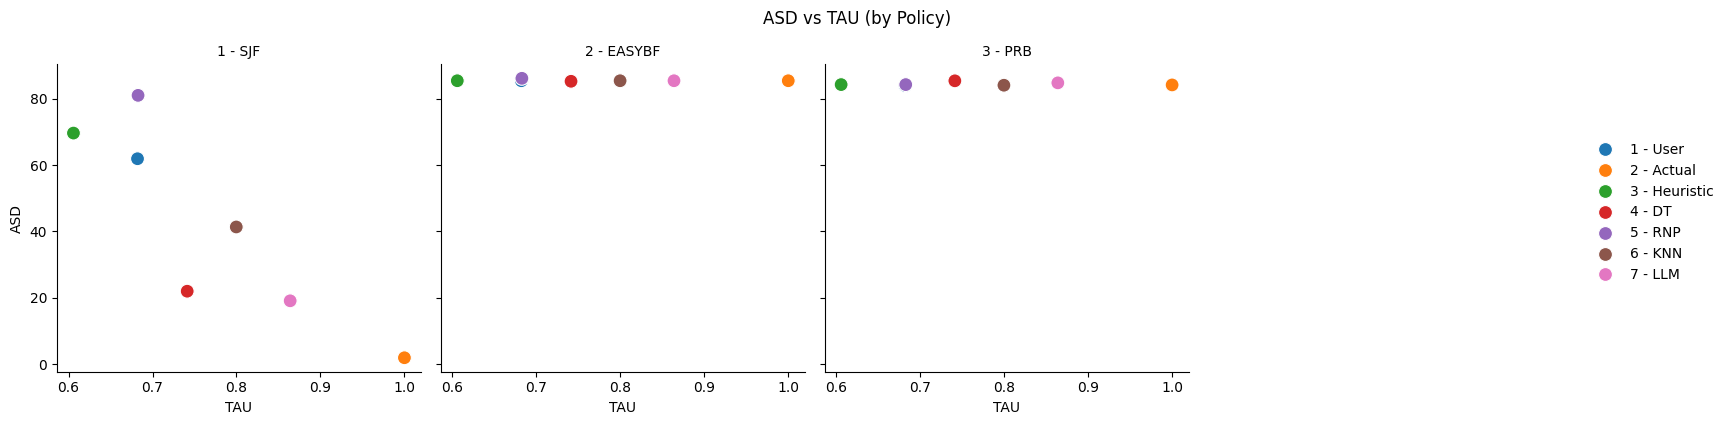

In [55]:
accuracy_vs_metric_by_policy(summary_df_avg, "MAE", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "MAE", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "EA", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "EA", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "MAPE", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "MAPE", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "TAU", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "TAU", "ASD")

### Metrics Regression

#### Helpers

In [56]:
def plot_feature_importance(model, X, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure()
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

In [57]:
def plot_permutation_importance(model, X, y, title):
    result = permutation_importance(
        model, X, y,
        n_repeats=30,
        random_state=42
    )

    sorted_idx = result.importances_mean.argsort()

    plt.figure()
    plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(title)
    plt.show()

In [58]:
def plot_pdp(model, X, features, title, size=(12, 12)):
    fig, ax = plt.subplots(figsize=size)

    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features,
        ax=ax
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#### Random Forest - All Metrics

In [59]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
        "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

X = summary_df[features]

# --- targets
y_awt = summary_df["AWT"]
y_asd = summary_df["ASD"]

In [60]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

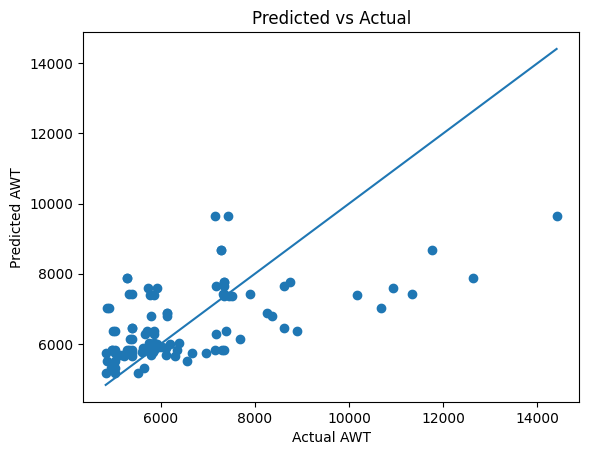

In [61]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

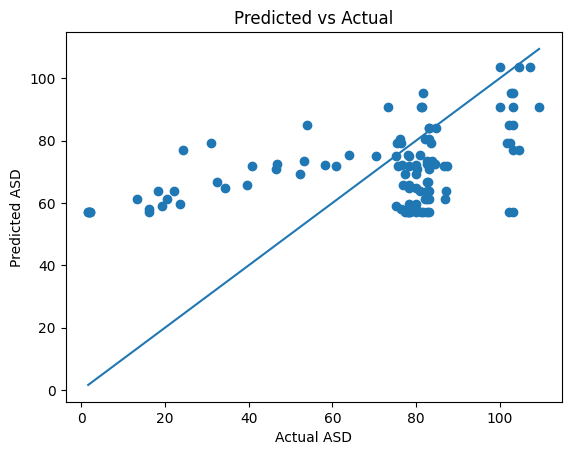

In [62]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

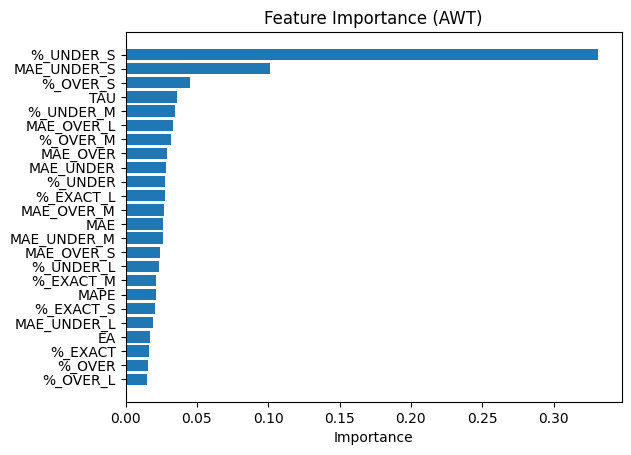

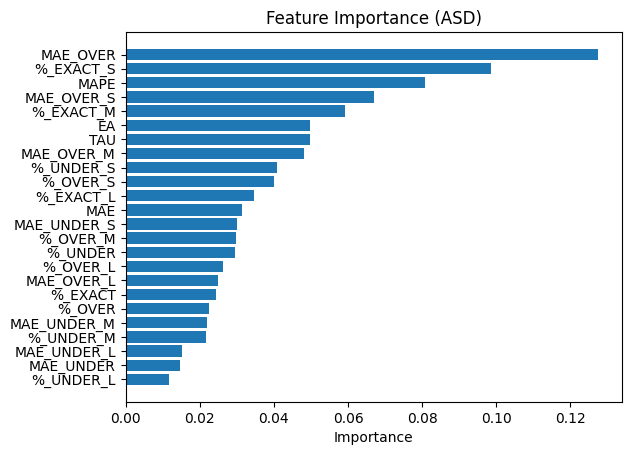

In [63]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

#### Random Forest - Reduced Metrics

In [64]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT"]

X = summary_df[features]

# --- targets
y_awt = summary_df["AWT"]
y_asd = summary_df["ASD"]

In [65]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

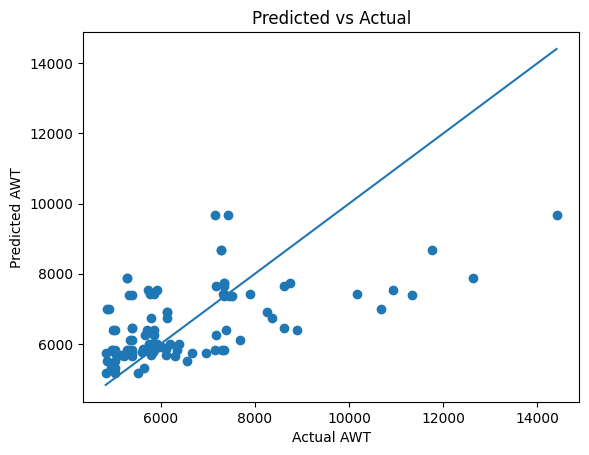

In [66]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

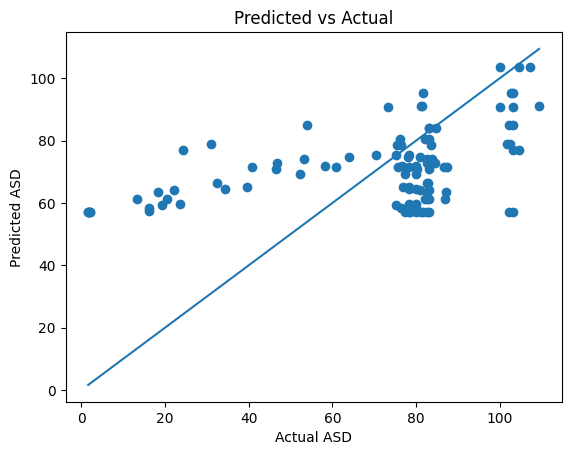

In [67]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

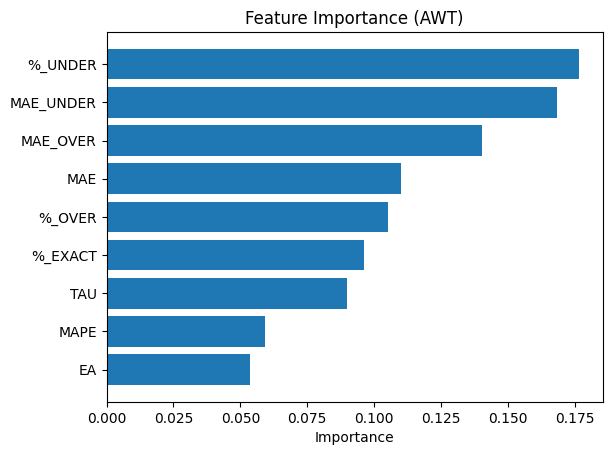

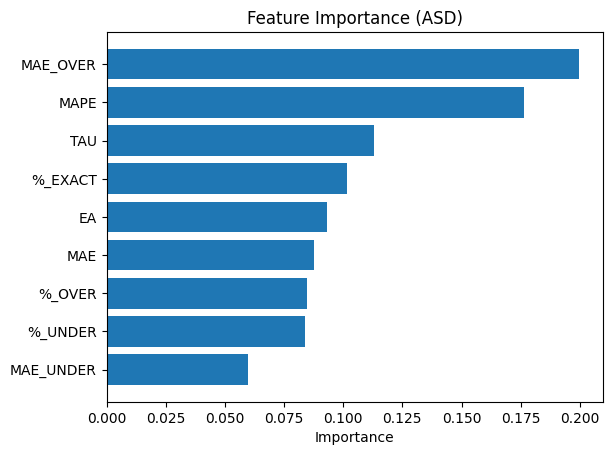

In [68]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

## SJF-specific Analysis

### Data Preprocessing

In [69]:
summary_df_sjf = summary_df[summary_df["Policy"] == "1 - SJF"]

In [70]:
summary_df_sjf

,Workload,Policy,Estimation,AWT,ASD,Average Error,MAE,EA,MAPE,TAU,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - SJF,1 - User,6564.22,60.95,03:32:14,12734.325333,0.415510,16.712898,0.684601,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,1 - SJF,2 - Actual,5322.34,1.73,00:00:00,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,1 - SJF,3 - Heuristic,6968.10,70.34,01:12:42,4362.756722,0.527931,5.916221,0.602494,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,1 - SJF,4 - DT,8898.37,16.23,00:45:32,2732.920278,0.686213,0.813249,0.740257,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,1 - SJF,5 - RNP,10672.49,83.55,00:54:17,3257.819000,0.635233,1.903771,0.684629,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
5,Heavy_1,1 - SJF,6 - KNN,5644.64,39.62,00:38:27,2307.369278,0.729893,4.477197,0.797298,...,1706.538497,0.198223,0.695155,0.106622,10644.637011,5324.526606,13185.794040,0.323250,0.676750,0.000000
6,Heavy_1,1 - SJF,7 - LLM,5510.67,19.40,00:28:23,1703.435833,0.851143,2.177579,0.862404,...,2000.652124,0.378358,0.366088,0.255553,5275.701068,3850.065183,9155.786421,0.373072,0.419336,0.207592
21,Heavy_2,1 - SJF,1 - User,6029.04,46.85,03:33:49,12829.908444,0.416444,14.670395,0.684215,...,0.000000,1.000000,0.000000,0.000000,31036.813481,31036.813481,0.000000,1.000000,0.000000,0.000000
22,Heavy_2,1 - SJF,2 - Actual,4961.21,1.69,00:00:00,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
23,Heavy_2,1 - SJF,3 - Heuristic,6198.26,53.30,01:13:36,4416.000889,0.533155,5.233531,0.611068,...,5064.012156,0.473308,0.525946,0.000746,18540.604881,7034.406375,23279.006563,0.291691,0.708309,0.000000


In [71]:
summary_df_sjf_avg = (
    summary_df_sjf
    .groupby(["Policy", "Estimation"])
    .agg({
        "AWT": "mean",
        "ASD": "mean",
        "MAE": "mean",
        "MAPE": "mean",
        "EA": "mean",
        "TAU": "mean",
        "MAE_OVER": "mean",
        "MAE_UNDER": "mean",
        "%_OVER": "mean",
        "%_UNDER": "mean",
        "%_EXACT": "mean",
        "MAE_OVER_S": "mean", 
        "MAE_UNDER_S": "mean", 
        "%_OVER_S": "mean", 
        "%_UNDER_S": "mean", 
        "%_EXACT_S": "mean",
        "MAE_OVER_M": "mean", 
        "MAE_UNDER_M": "mean", 
        "%_OVER_M": "mean", 
        "%_UNDER_M": "mean", 
        "%_EXACT_M": "mean",
        "MAE_OVER_L": "mean", 
        "MAE_UNDER_L": "mean", 
        "%_OVER_L": "mean", 
        "%_UNDER_L": "mean", 
        "%_EXACT_L": "mean"

    })
    .reset_index()
)

In [72]:
summary_df_sjf_avg

,Policy,Estimation,AWT,ASD,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,...,MAE_OVER_M,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,1 - SJF,1 - User,7251.168,61.902,12944.616278,16.420116,0.416574,0.682113,12944.616278,0.000000,...,14510.251234,0.000000,1.000000,0.000000,0.000000,30881.306740,0.000000,1.000000,0.000000,0.000000
1,1 - SJF,2 - Actual,5894.516,1.916,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,1 - SJF,3 - Heuristic,7540.970,69.636,4422.624133,5.704651,0.531842,0.605823,2572.628424,6942.287194,...,3200.552784,5052.687105,0.467705,0.531828,0.000467,6795.491343,22529.933724,0.289303,0.710347,0.000351
3,1 - SJF,4 - DT,10105.480,21.972,2752.039100,1.187079,0.686988,0.741282,2116.760024,3670.984123,...,1962.689233,1611.008757,0.405133,0.505432,0.089435,8703.718617,21523.902723,0.347889,0.650499,0.001612
4,1 - SJF,5 - RNP,11377.402,81.004,3322.679467,2.021775,0.633978,0.682761,3914.224952,2947.508449,...,3664.343814,1345.009707,0.418542,0.533528,0.047930,14268.167654,20151.627481,0.442526,0.557474,0.000000
5,1 - SJF,6 - KNN,6366.696,41.336,2319.194689,4.279333,0.732669,0.799715,2132.038049,2729.258796,...,3757.436115,1717.646993,0.202765,0.693531,0.103704,5281.005384,12703.550987,0.315088,0.684912,0.000000
6,1 - SJF,7 - LLM,6180.996,19.080,1672.592856,1.917639,0.852813,0.863918,2438.226605,2303.231721,...,3316.189108,1957.662618,0.388250,0.364378,0.247372,3497.052896,9220.844608,0.368561,0.420816,0.210623


In [73]:
predictions = pd.read_csv("predictions/fdata/predictions.csv")

w_1800_1 = pd.read_csv('workloads/fdata/fdata_18k_1.swf', sep="\t", header=None)
w_1800_2 = pd.read_csv('workloads/fdata/fdata_18k_2.swf', sep="\t", header=None)
w_1800_3 = pd.read_csv('workloads/fdata/fdata_18k_3.swf', sep="\t", header=None)
w_1800_4 = pd.read_csv('workloads/fdata/fdata_18k_4.swf', sep="\t", header=None)
w_1800_5 = pd.read_csv('workloads/fdata/fdata_18k_5.swf', sep="\t", header=None)

pred_w_1800_1 = predictions[predictions["job_id"].isin(w_1800_1[0].values)]
pred_w_1800_2 = predictions[predictions["job_id"].isin(w_1800_2[0].values)]
pred_w_1800_3 = predictions[predictions["job_id"].isin(w_1800_3[0].values)]
pred_w_1800_4 = predictions[predictions["job_id"].isin(w_1800_4[0].values)]
pred_w_1800_5 = predictions[predictions["job_id"].isin(w_1800_5[0].values)]

In [74]:
ESTIMATION_COL_MAP = {
    "1 - User": "pred_runtime_user",
    "3 - Heuristic": "pred_runtime_heuristic",
    "4 - DT": "pred_runtime_dt",
    "5 - RNP": "pred_runtime_rnp",
    "6 - KNN": "pred_runtime_knn",
    "7 - LLM": "pred_runtime_llm",
}

pred_dfs = {
    "Heavy_1": pred_w_1800_1,
    "Heavy_2": pred_w_1800_2,
    "Heavy_3": pred_w_1800_3,
    "Heavy_4": pred_w_1800_4,
    "Heavy_5": pred_w_1800_5,
}

In [75]:
job_rows = []

for workload, df in pred_dfs.items():
    for est_label, pred_col in ESTIMATION_COL_MAP.items():

        tmp = df[[
            "job_id",
            "user_id",
            "time_submit",
            "gt_runtime",
            pred_col
        ]].copy()

        tmp = tmp.rename(columns={
            pred_col: "predicted_runtime",
            "gt_runtime": "true_runtime"
        })

        tmp["Workload"] = workload
        tmp["Policy"] = "1 - SJF"
        tmp["Estimation"] = est_label

        job_rows.append(tmp)

job_df = pd.concat(job_rows, ignore_index=True)

In [76]:
job_df

,job_id,user_id,time_submit,true_runtime,predicted_runtime,Workload,Policy,Estimation
0,8773159,299,1894044,686,3600,Heavy_1,1 - SJF,1 - User
1,8688724,299,1894045,703,3600,Heavy_1,1 - SJF,1 - User
2,8773164,299,1894045,708,3600,Heavy_1,1 - SJF,1 - User
3,8773166,299,1894045,703,3600,Heavy_1,1 - SJF,1 - User
4,8687155,1122,1894048,2,1800,Heavy_1,1 - SJF,1 - User
...,...,...,...,...,...,...,...,...
539995,8770905,1214,2432738,663,700,Heavy_5,1 - SJF,7 - LLM
539996,8770992,1214,2432740,670,670,Heavy_5,1 - SJF,7 - LLM
539997,8770999,1214,2432741,655,636,Heavy_5,1 - SJF,7 - LLM
539998,8771019,1214,2432742,666,666,Heavy_5,1 - SJF,7 - LLM


In [77]:
job_df[["true_runtime", "predicted_runtime"]].describe()

,true_runtime,predicted_runtime
count,540000.000000,540000.000000
mean,9160.310678,10923.862065
std,20303.063557,23878.903206
min,1.000000,1.000000
25%,202.000000,600.000000
50%,3605.000000,3605.000000
75%,12819.000000,12475.000000
max,257966.000000,259200.000000


### Correlation Tables

In [78]:
corr_cols = [
    "AWT", "ASD",
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df_sjf_avg[corr_cols].corr()

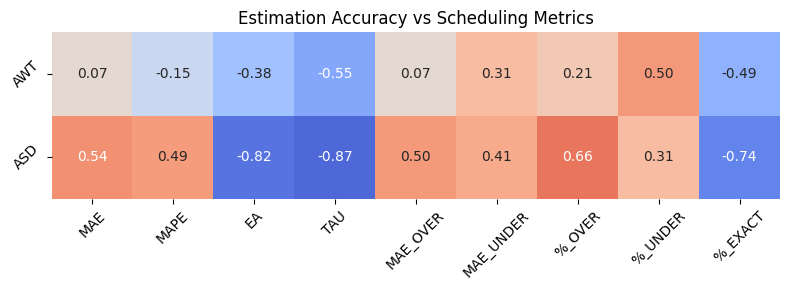

In [79]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -9:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.savefig("images/18000x158976/correlation_sjf_F2.png", dpi=300)
plt.show()

In [80]:
corr_cols = [
    "AWT", "ASD",
    "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

corr = summary_df_sjf_avg[corr_cols].corr()

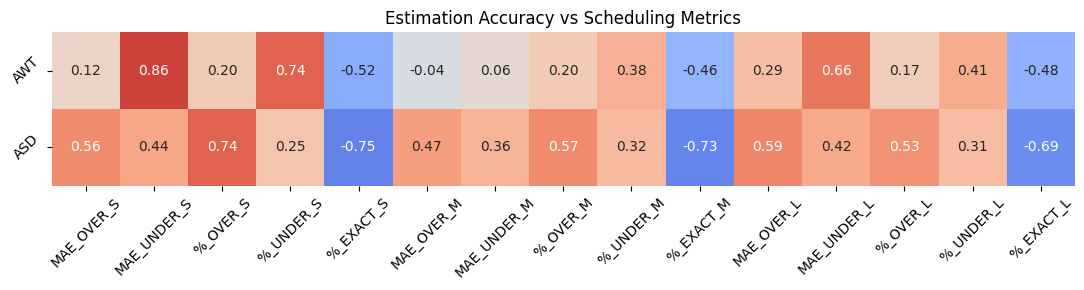

In [81]:
plt.figure(figsize=(11, 3))
sns.heatmap(corr.iloc[0:2, -15:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [82]:
corr_cols = [
    "AWT", "ASD",
    "MAE", "MAPE", "EA", "TAU"
]

corr = summary_df_sjf_avg[corr_cols].corr()

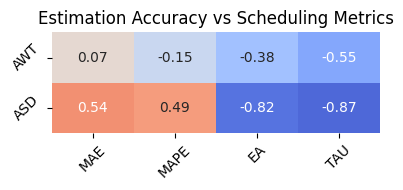

In [83]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.savefig("images/18000x158976/correlation_main_sjf_F2.png", dpi=300)
plt.show()

In [84]:
corr_cols = [
    "AWT", "ASD",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df_sjf[corr_cols].corr()

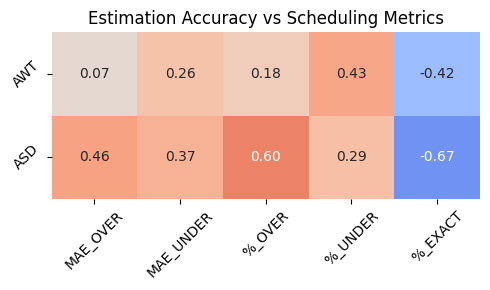

In [85]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [86]:
corr_cols = [
    "AWT", "ASD",
    "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S"
]

corr = summary_df_sjf[corr_cols].corr()

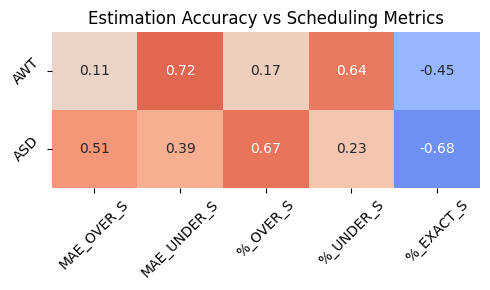

In [87]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [88]:
corr_cols = [
    "AWT", "ASD",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M"
]

corr = summary_df_sjf[corr_cols].corr()

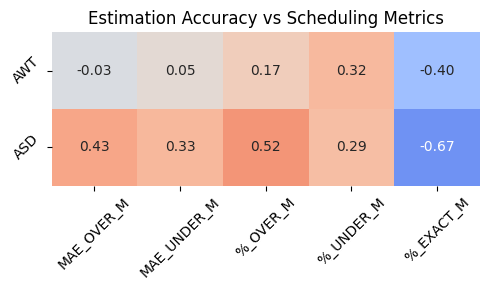

In [89]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [90]:
corr_cols = [
    "AWT", "ASD",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

corr = summary_df_sjf[corr_cols].corr()

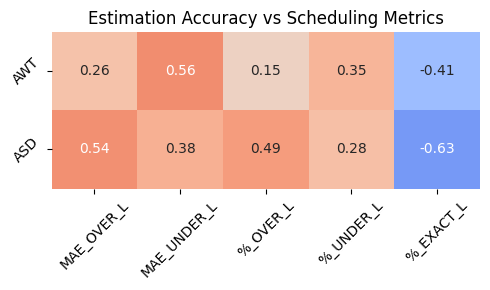

In [91]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

### Scatter plots: Accuracy → Performance

In [95]:
def accuracy_vs_metrics_grid(data, acc_metrics, sched_metrics, size=(12, 12), image_path=""):
    fig, axes = plt.subplots(
        nrows=len(acc_metrics),
        ncols=len(sched_metrics),
        figsize=size,
        sharex=False,
        sharey=False
    )

    for i, acc_metric in enumerate(acc_metrics):
        for j, sched_metric in enumerate(sched_metrics):
            ax = axes[i, j]

            # Show legend only for last column
            show_legend = (j == len(sched_metrics) - 1)

            sns.scatterplot(
                data=data,
                x=acc_metric,
                y=sched_metric,
                hue="Estimation",
                s=50,
                ax=ax,
                legend=show_legend
            )

            ax.set_title(f"{sched_metric} vs {acc_metric}")
            ax.grid(True)

            # Move legend to the right of the last subplot
            if show_legend:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(
                    handles=handles,
                    labels=labels,
                    loc='center left',
                    bbox_to_anchor=(1.05, 0.5),
                    borderaxespad=0.
                )

    plt.tight_layout()

    # Add extra space on the right for legends
    plt.subplots_adjust(right=0.85)

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")

    plt.show()


def accuracy_vs_metrics_compact(data, acc_metrics, sched_metrics, size=(12, 4), image_path=""):
    # Crea una copia per evitare di modificare il dataframe originale
    df_plot = data.copy()

    # 1. Normalizzazione MAE e MAPE tra 0 e 1 basata sul valore massimo
    for col in ["MAE", "MAPE"]:
        if col in df_plot.columns:
            max_val = df_plot[col].max()
            if max_val != 0:
                df_plot[col] = df_plot[col] / max_val

    # 1. Normalizzazione MAE e MAPE tra 0 e 1 basata sul valore massimo
    for col in ["AWT", "ASD"]:
        if col in df_plot.columns:
            min_val = df_plot[col].min()
            if min_val != 0:
                df_plot[col] = df_plot[col] / min_val

    # 2. Setup dei subplots: solo 2 colonne (una per ogni sched_metric)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(sched_metrics),
        figsize=size,
        sharey=False
    )

    # Se c'è solo una sched_metric, axes non è una lista, lo rendiamo tale
    if len(sched_metrics) == 1:
        axes = [axes]

    # Definiamo dei marker specifici per le 4 acc_metrics
    marker_map = {"MAE": "o", "MAPE": "s", "EA": "D", "TAU": "X"}

    for j, sched_metric in enumerate(sched_metrics):
        ax = axes[j]
        
        # Trasformiamo il dataframe in "long format" per avere le acc_metrics come variabile
        # Questo permette di usare 'style' per cambiare i marker
        df_melted = df_plot.melt(
            id_vars=["Estimation", sched_metric], 
            value_vars=acc_metrics, 
            var_name="Accuracy Metric", 
            value_name="Metric_Value"
        )

        sns.scatterplot(
            data=df_melted,
            x="Metric_Value",
            y=sched_metric,
            hue="Estimation",
            style="Accuracy Metric",
            markers=marker_map,
            s=80,
            ax=ax,
            alpha=0.7
        )

        # 3. Limiti dei plot tra -1 e 1
        if acc_metrics == ["MAE", "MAPE"]:
            ax.set_xlim(0, 1)
        elif acc_metrics == ["EA", "TAU"]:
            ax.set_xlim(-1, 1)
        
        ax.set_title(f"Impact on {sched_metric}")
        ax.set_xlabel("Normalized Metric Value")
        ax.grid(True, linestyle='--', alpha=0.6)

        # Gestione legenda: la mettiamo solo sul secondo plot per non intasare
        if j == len(sched_metrics) - 1:
            ax.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.get_legend().remove()

    plt.tight_layout()

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")

    plt.show()

Grafico salvato in: images/18000x158976/scatter_plots_sjf_F2.png


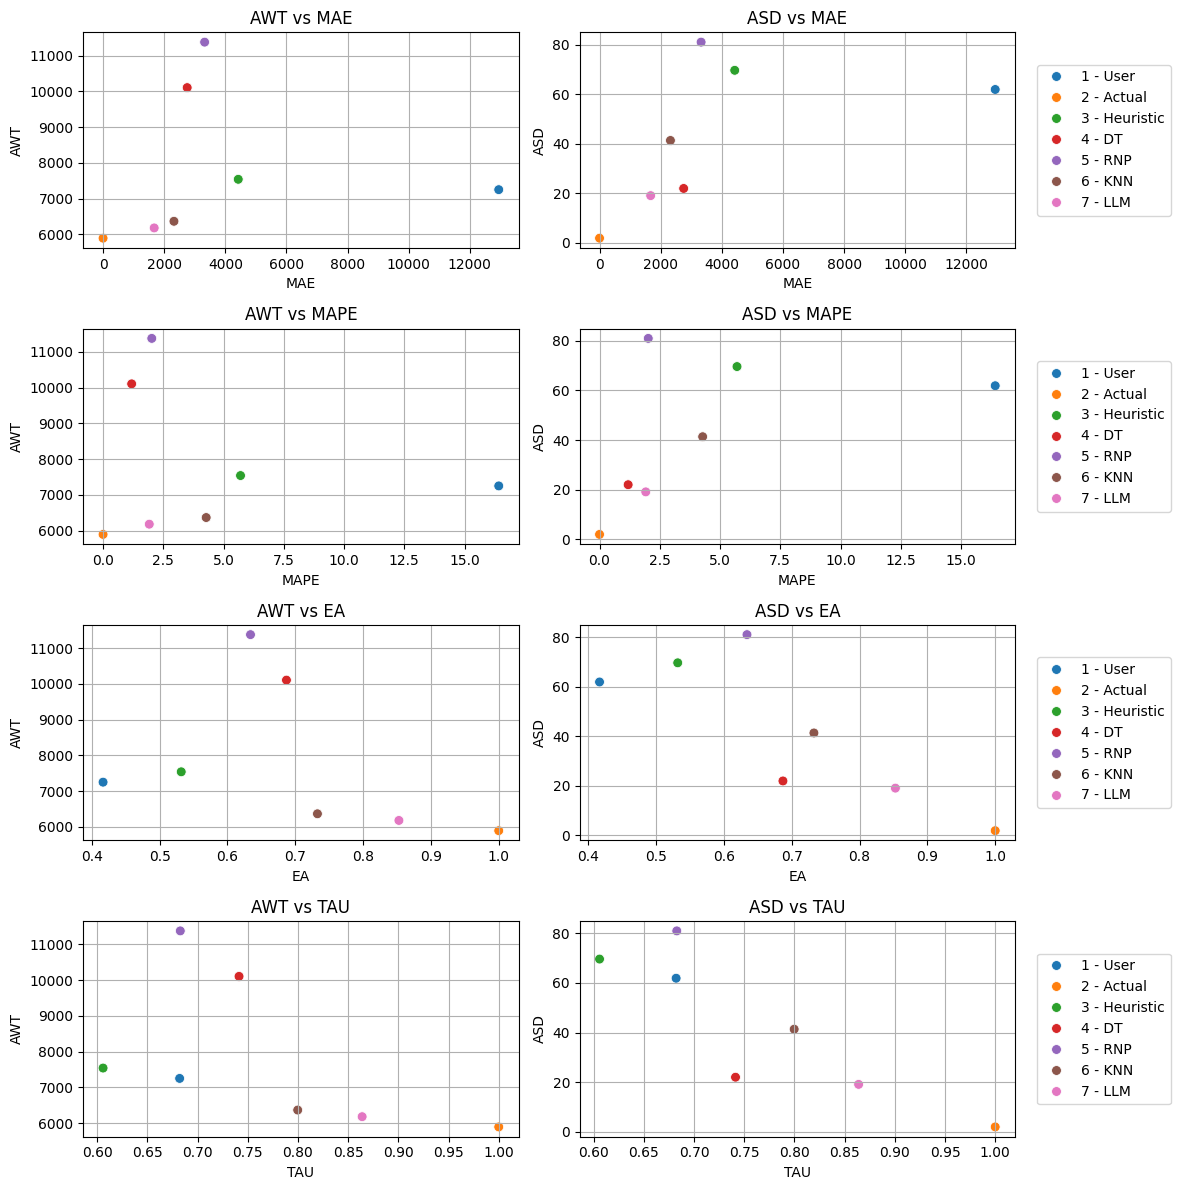

In [93]:
acc_metrics = ["MAE", "MAPE", "EA", "TAU"]
sched_metrics = ["AWT", "ASD"]

accuracy_vs_metrics_grid(summary_df_sjf_avg, acc_metrics, sched_metrics, image_path="images/18000x158976/scatter_plots_sjf_F2.png")

Grafico salvato in: images/18000x158976/scatter_plots_sjf_F2_1.png


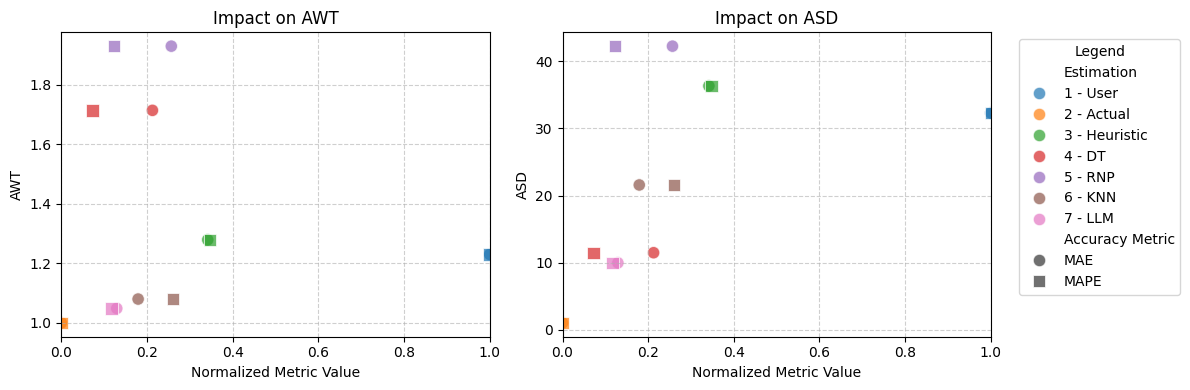

Grafico salvato in: images/18000x158976/scatter_plots_sjf_F2_2.png


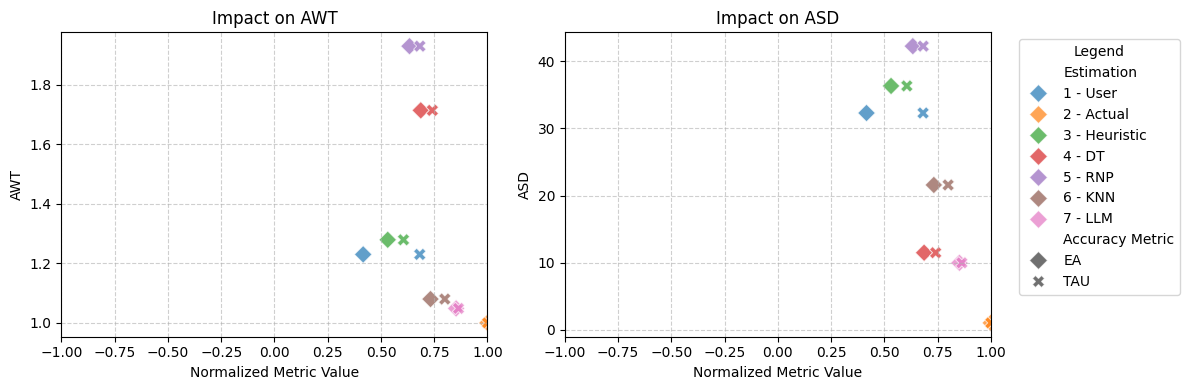

In [96]:
acc_metrics = ["MAE", "MAPE"]
sched_metrics = ["AWT", "ASD"]

# accuracy_vs_metrics_compact(summary_df_sjf_avg, acc_metrics, sched_metrics)
accuracy_vs_metrics_compact(summary_df_sjf_avg, acc_metrics, sched_metrics, image_path="images/18000x158976/scatter_plots_sjf_F2_1.png")

acc_metrics = ["EA", "TAU"]
sched_metrics = ["AWT", "ASD"]

# accuracy_vs_metrics_compact(summary_df_sjf_avg, acc_metrics, sched_metrics)
accuracy_vs_metrics_compact(summary_df_sjf_avg, acc_metrics, sched_metrics, image_path="images/18000x158976/scatter_plots_sjf_F2_2.png")

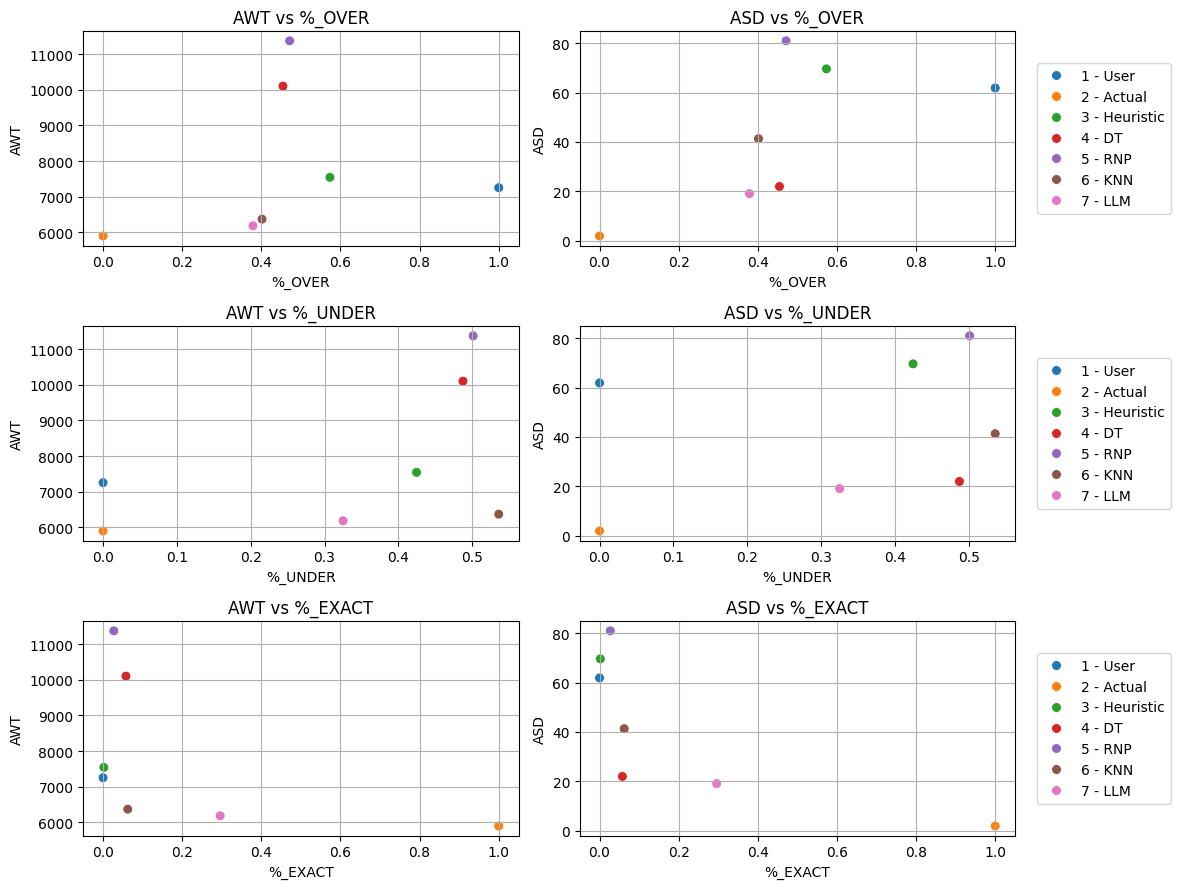

In [95]:
acc_metrics = ["%_OVER", "%_UNDER", "%_EXACT"]
sched_metrics = ["AWT", "ASD"]

accuracy_vs_metrics_grid(summary_df_sjf_avg, acc_metrics, sched_metrics, size=(12, 9))

### Rank–Rank Correlation

In [96]:
def rank_rank_correlation(summary_df, sched_metric, acc_metric, method_col="Estimation"):
    """
    summary_df: one row per estimation method (SJF only)
    """
    df = summary_df.copy()

    # Rank: lower scheduling metric is better, higher accuracy is better
    df["sched_rank"] = df[sched_metric].rank(ascending=True)
    df["acc_rank"] = df[acc_metric].rank(ascending=False)

    kendall = kendalltau(df["sched_rank"], df["acc_rank"])
    spearman = spearmanr(df["sched_rank"], df["acc_rank"])

    return {
        "kendall_tau": kendall.correlation,
        "spearman_r": spearman.correlation
    }

In [97]:
print("AWT vs MAE")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE"))
print("ASD vs MAE")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE"))
print("AWT vs MAPE")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAPE"))
print("ASD vs MAPE")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAPE"))
print("AWT vs EA")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "EA"))
print("ASD vs EA")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "EA"))
print("AWT vs TAU")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "TAU"))
print("ASD vs TAU")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "TAU"))

AWT vs MAE
{'kendall_tau': np.float64(-0.5238095238095238), 'spearman_r': np.float64(-0.6785714285714287)}
ASD vs MAE
{'kendall_tau': np.float64(-0.6190476190476191), 'spearman_r': np.float64(-0.8214285714285715)}
AWT vs MAPE
{'kendall_tau': np.float64(-0.23809523809523814), 'spearman_r': np.float64(-0.28571428571428575)}
ASD vs MAPE
{'kendall_tau': np.float64(-0.5238095238095238), 'spearman_r': np.float64(-0.7142857142857144)}
AWT vs EA
{'kendall_tau': np.float64(0.5238095238095238), 'spearman_r': np.float64(0.6785714285714287)}
ASD vs EA
{'kendall_tau': np.float64(0.6190476190476191), 'spearman_r': np.float64(0.8214285714285715)}
AWT vs TAU
{'kendall_tau': np.float64(0.6190476190476191), 'spearman_r': np.float64(0.7142857142857144)}
ASD vs TAU
{'kendall_tau': np.float64(0.7142857142857143), 'spearman_r': np.float64(0.8571428571428573)}


In [98]:
print("AWT vs MAE_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_OVER"))
print("ASD vs MAE_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_OVER"))
print("AWT vs MAE_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_UNDER"))
print("ASD vs MAE_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_UNDER"))

AWT vs MAE_OVER
{'kendall_tau': np.float64(-0.33333333333333337), 'spearman_r': np.float64(-0.4642857142857144)}
ASD vs MAE_OVER
{'kendall_tau': np.float64(-0.6190476190476191), 'spearman_r': np.float64(-0.7857142857142859)}
AWT vs MAE_UNDER
{'kendall_tau': np.float64(-0.4879500364742666), 'spearman_r': np.float64(-0.702731220902536)}
ASD vs MAE_UNDER
{'kendall_tau': np.float64(-0.39036002917941326), 'spearman_r': np.float64(-0.5045249791095131)}


### Metrics Regression

#### Helpers

In [99]:
def plot_feature_importance(model, X, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure()
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

def plot_combined_feature_importance(model1, model2, X, title1, title2, image_path=""):
    # Create a figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    models = [model1, model2]
    axes = [ax1, ax2]
    titles = [title1, title2]

    for model, ax, title in zip(models, axes, titles):
        importances = model.feature_importances_
        indices = np.argsort(importances)

        # Plot on the specific axis (ax) instead of plt
        ax.barh(range(len(indices)), importances[indices], color='skyblue', edgecolor='black')
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels(X.columns[indices])
        ax.set_xlabel("Importance")
        ax.set_title(title)

    plt.tight_layout()

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
        
    plt.show()

In [100]:
def plot_permutation_importance(model, X, y, title):
    result = permutation_importance(
        model, X, y,
        n_repeats=30,
        random_state=42
    )

    sorted_idx = result.importances_mean.argsort()

    plt.figure()
    plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(title)
    plt.show()

In [101]:
def plot_pdp(model, X, features, title, size=(12, 12)):
    fig, ax = plt.subplots(figsize=size)

    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features,
        ax=ax
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [102]:
def plot_loocv(y_true, y_pred, title, ylabel):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])
    plt.xlabel("Actual")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [103]:
def bootstrap_importance(X, y, n_runs=200):
    importances = []

    for _ in range(n_runs):
        idx = np.random.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[idx]
        y_sample = y.iloc[idx]

        rf = RandomForestRegressor(n_estimators=200)
        rf.fit(X_sample, y_sample)

        importances.append(rf.feature_importances_)

    importances = np.array(importances)

    return importances.mean(axis=0), importances.std(axis=0)

def plot_importance(mean_imp, std_imp, feature_names, title):
    plt.figure()
    plt.barh(feature_names, mean_imp, xerr=std_imp)
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

In [104]:
def scatter_plot(df, x_col, y_col):
    plt.figure()
    plt.scatter(df[x_col], df[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.show()

#### Random Forest - All Metrics

In [105]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

X = summary_df_sjf[features]

# --- targets
y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [106]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

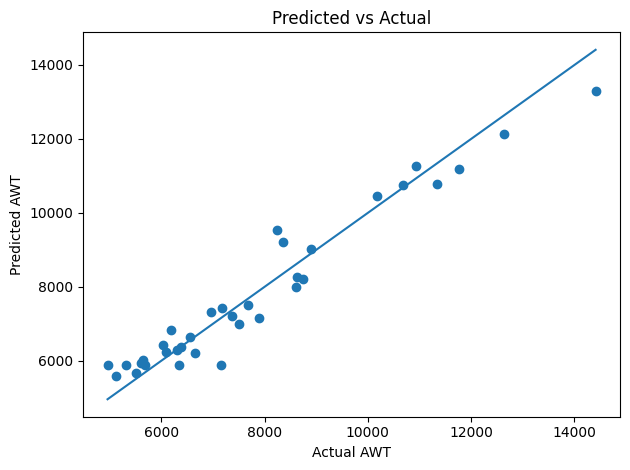

In [107]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.tight_layout()
plt.savefig("images/18000x158976/awt_regression_sjf_F2.png", dpi=300)
plt.show()

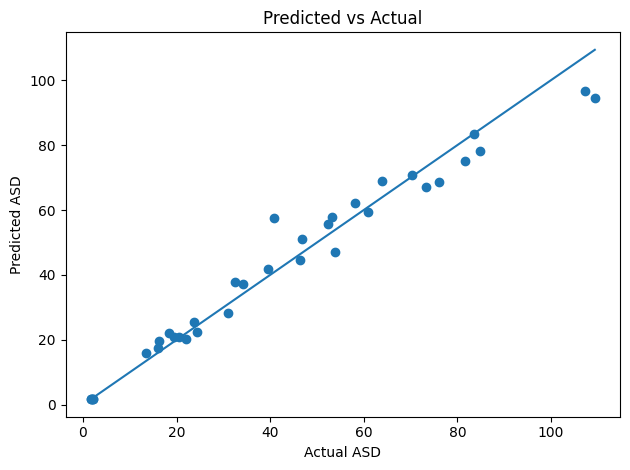

In [108]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.tight_layout()
plt.savefig("images/18000x158976/asd_regression_sjf_F2.png", dpi=300)
plt.show()

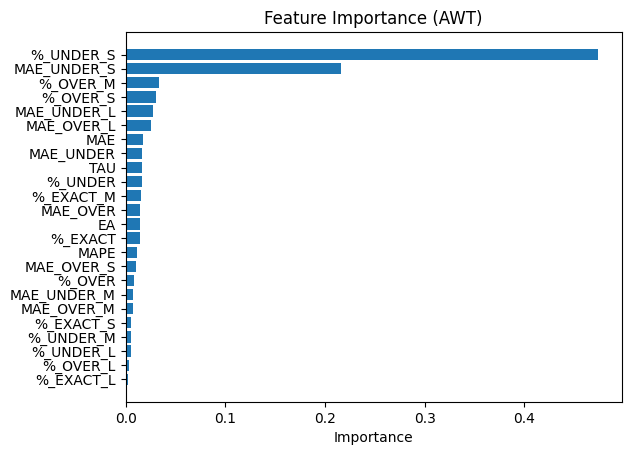

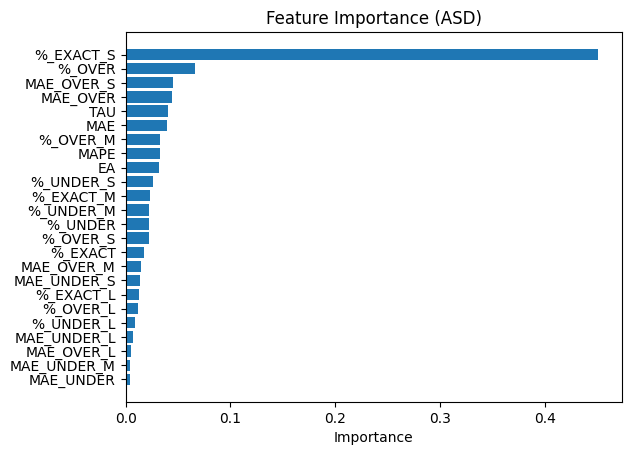

In [109]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

Grafico salvato in: images/18000x158976/feature_importance_sjf_F2.png


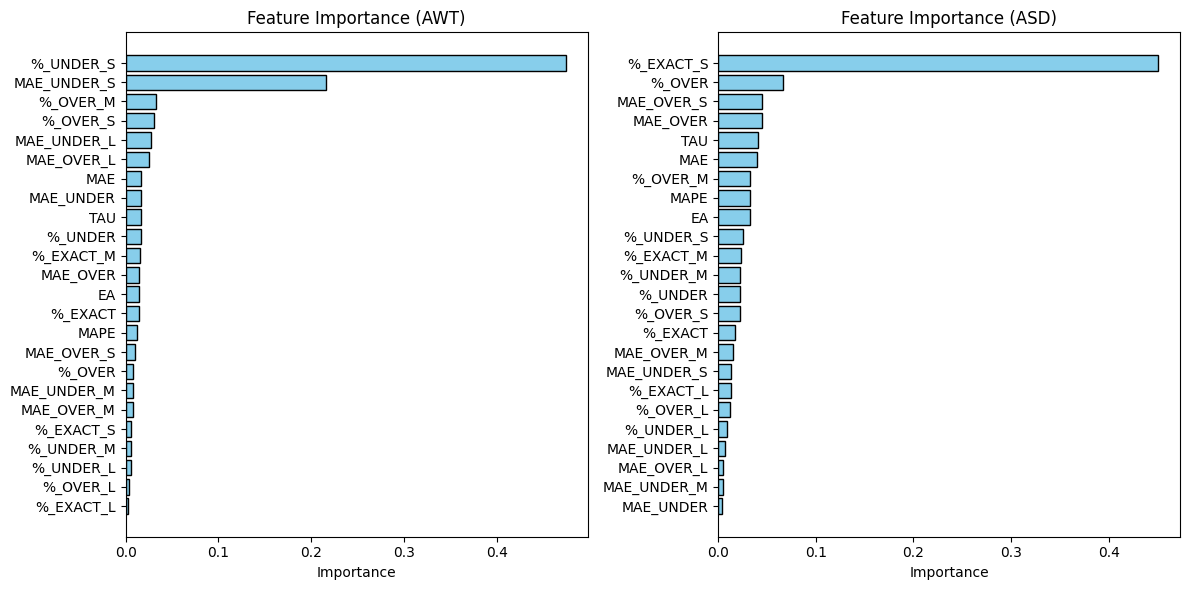

In [110]:
plot_combined_feature_importance(rf_awt, rf_asd, X, "Feature Importance (AWT)", "Feature Importance (ASD)", "images/18000x158976/feature_importance_sjf_F2.png")

#### Random Forest - Reduced Metrics

In [111]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT"]

X = summary_df_sjf[features]

# --- targets
y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [112]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

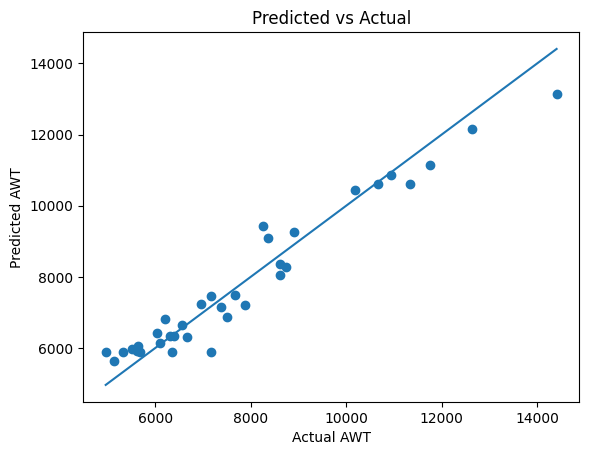

In [113]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

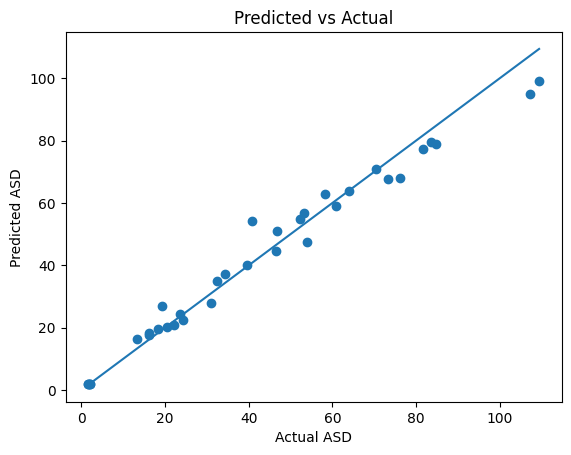

In [114]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

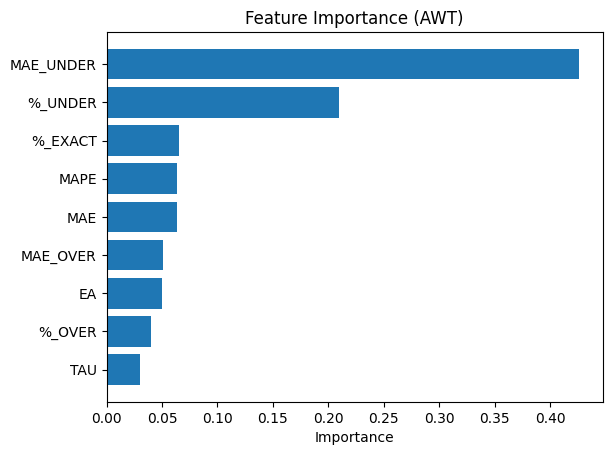

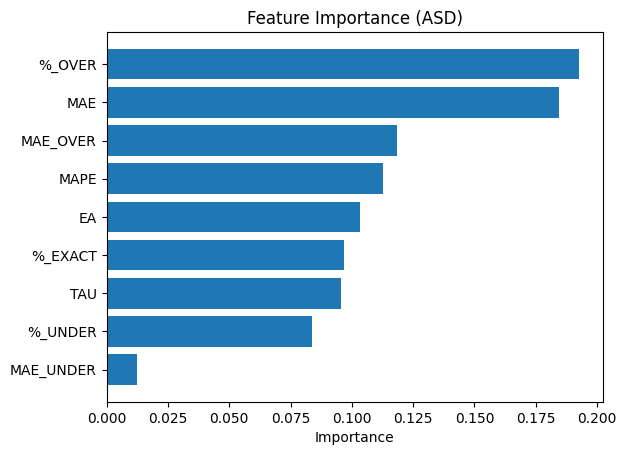

In [115]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

#### Random Forest + LOO-CV

In [116]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_OVER_S", "MAE_UNDER_S", "%_OVER_S", "%_UNDER_S", "%_EXACT_S",
    "MAE_OVER_M", "MAE_UNDER_M", "%_OVER_M", "%_UNDER_M", "%_EXACT_M",
    "MAE_OVER_L", "MAE_UNDER_L", "%_OVER_L", "%_UNDER_L", "%_EXACT_L"
]

X = summary_df_sjf[features]

y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [117]:
loo = LeaveOneOut()

rf_awt = RandomForestRegressor(n_estimators=300, random_state=42)
rf_asd = RandomForestRegressor(n_estimators=300, random_state=42)

# --- LOOCV predictions
y_pred_awt = cross_val_predict(rf_awt, X, y_awt, cv=loo)
y_pred_asd = cross_val_predict(rf_asd, X, y_asd, cv=loo)

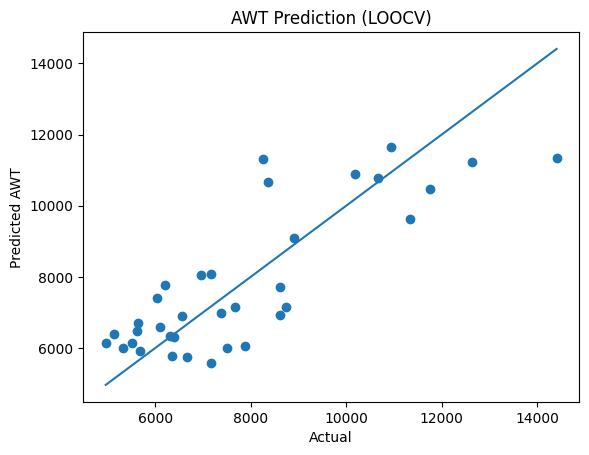

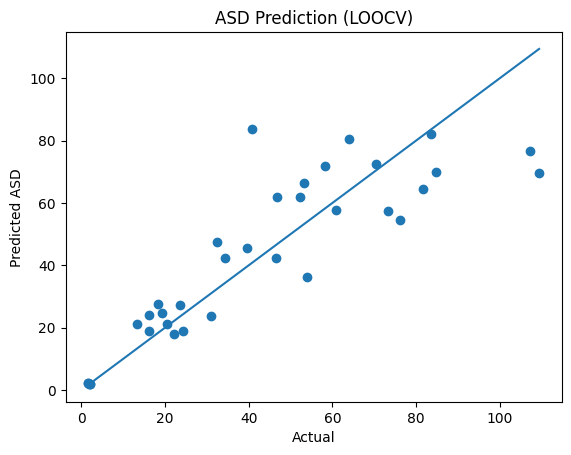

In [118]:
plot_loocv(y_awt, y_pred_awt, "AWT Prediction (LOOCV)", "Predicted AWT")
plot_loocv(y_asd, y_pred_asd, "ASD Prediction (LOOCV)", "Predicted ASD")

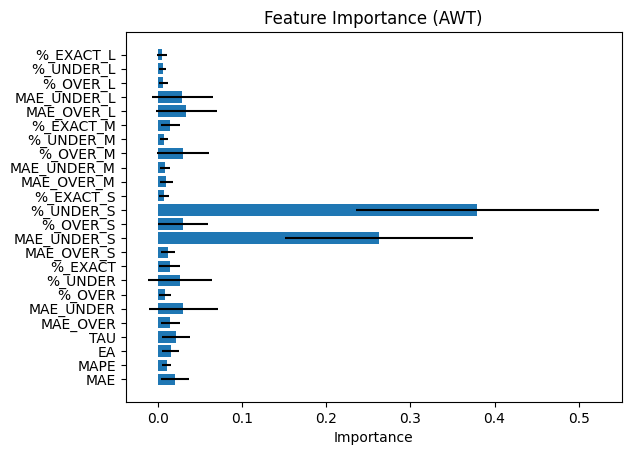

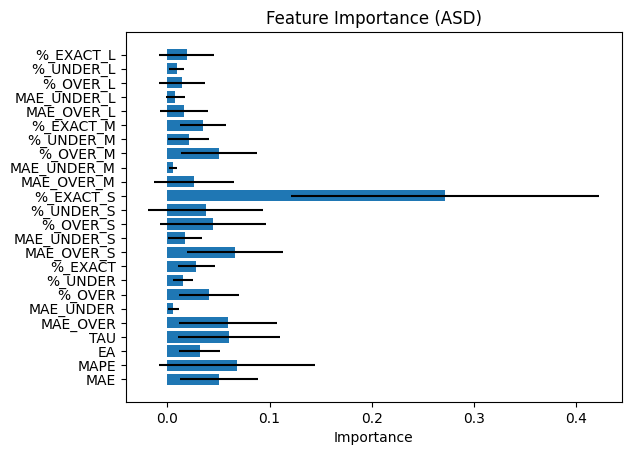

In [119]:
mean_awt, std_awt = bootstrap_importance(X, y_awt)
mean_asd, std_asd = bootstrap_importance(X, y_asd)

plot_importance(mean_awt, std_awt, X.columns, "Feature Importance (AWT)")
plot_importance(mean_asd, std_asd, X.columns, "Feature Importance (ASD)")